# Baby Sleep Detection — Load, Preprocess & Feature Engineering

## What this notebook does
This notebook covers **Step 1 and Step 2** of the full pipeline:
- **Step 1 — Load & Split:** Read the raw dataset efficiently without crashing RAM, then split into train/test at the child (series) level to prevent data leakage
- **Step 2 — Preprocess & Feature Engineering:** Clean the data, engineer features, scale, and balance classes — all done independently on train and test

## Why Kaggle instead of Colab?
The raw series file is ~3 GB. Colab's 12 GB RAM crashes when loading it. Kaggle gives 30 GB RAM and the dataset is already mounted — no download needed.

## Resume-safe design
Every major step saves its output to `/kaggle/working/` as a `.parquet` or `.npy` file before the next step begins. If the notebook crashes or times out, re-run only the cells you haven't completed — already-saved files are detected and skipped automatically.

## Leakage prevention strategy
| Risk | Fix applied |
|------|-------------|
| Same child in train and test | `GroupShuffleSplit` on `series_id` |
| Future labels leaking into past rows | `merge_asof(direction='backward')` |
| Scaler fitted on test data | Fit scaler on train only, apply to test |
| Clip bounds from test data | Compute bounds on train only, apply to test |
| Class balancing on test | Balancing applied to train only |

---
## CELL 1 — Imports & Configuration
All libraries used here come pre-installed on Kaggle — no `pip install` needed.

**Key constants:**
- `CHUNK_ROWS`: how many rows to read at once from the parquet file. 500k rows ≈ 200 MB RAM peak — safe for Kaggle's 30 GB
- `WINDOW_SAMPLES`: rolling window size for features. The CMI dataset runs at 1 sample per 5 seconds, so 24 samples = 2 minutes
- `SERIES_SCHEMA`: a fixed PyArrow schema applied to every batch to prevent the timestamp precision mismatch error (`timestamp[us]` vs `timestamp[ns]`) that occurs because different parquet row groups were written with different pandas versions

In [1]:
import gc
import json
import joblib
import warnings
import numpy  as np
import pandas as pd
import pyarrow         as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing   import RobustScaler
from sklearn.utils           import resample

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('/kaggle/input/competitions/child-mind-institute-detect-sleep-states')
WORK_DIR    = Path('/kaggle/working')
SERIES_FILE = DATA_DIR / 'train_series.parquet'
EVENTS_FILE = DATA_DIR / 'train_events.csv'

# ── Processing constants ──────────────────────────────────────────────────────
SAMPLE_RATE_HZ = 0.2           # CMI dataset: 1 sample every 5 seconds
CHUNK_ROWS     = 500_000       # rows per batch — keeps peak RAM ~200 MB per batch
WINDOW_SEC     = 120           # rolling window = 2 minutes
WINDOW_SAMPLES = int(WINDOW_SEC * SAMPLE_RATE_HZ)  # = 24 samples
RANDOM_SEED    = 42
TEST_SIZE      = 0.2           # 20% of children go to test set
BALANCE_RATIO  = 2             # keep 2 awake rows per 1 asleep row after balancing
G              = 9.80665       # m/s² per g — for MPU-6050 unit conversion

# ── Fixed schema — prevents timestamp[us] vs timestamp[ns] mismatch ──────────
# Different row groups in the CMI parquet were written with different pandas
# versions, resulting in mixed timestamp precision. Casting every batch to this
# fixed schema before writing ensures all output row groups match exactly.
SERIES_SCHEMA = pa.schema([
    ('series_id', pa.string()),
    ('step',      pa.int32()),
    ('timestamp', pa.timestamp('us', tz='UTC')),
    ('anglez',    pa.float32()),
    ('enmo',      pa.float32()),
])

# ── Feature column list (single source of truth) ─────────────────────────────
# Defined here so every later cell uses the exact same list and order.
# Order matters — the saved scaler and model expect this exact column order.
FEATURE_COLS = [
    'enmo_mean', 'enmo_std', 'enmo_max',
    'anglez_mean', 'anglez_std', 'anglez_abs_diff_mean',
    'minute_sin', 'minute_cos', 'is_night',
]

print('✓ Config loaded')
print(f'  Series file : {SERIES_FILE.name}  ({SERIES_FILE.stat().st_size/1e6:.0f} MB)')
print(f'  Events file : {EVENTS_FILE.name}  ({EVENTS_FILE.stat().st_size/1e6:.1f} MB)')
print(f'  Window      : {WINDOW_SAMPLES} samples = {WINDOW_SEC}s')

✓ Config loaded
  Series file : train_series.parquet  (986 MB)
  Events file : train_events.csv  (0.6 MB)
  Window      : 24 samples = 120s


---
## CELL 2 — Helper Functions

**`reduce_dtypes`**: Downcasts every numeric column to the smallest type that can hold its values. For example, `float64 → float32` halves memory for every float column. The CMI series has ~128 million rows, so this saves several gigabytes.

**`mem_mb`**: Quick check of how much RAM a DataFrame is using — used to verify savings at each step.

**`safe_to_datetime_utc`**: Converts any timestamp column to `datetime64[us, UTC]` consistently. This is the fix for the `MergeError` seen in Cell 7 — `merge_asof` requires both timestamp columns to have **exactly** the same dtype, including precision (`us` vs `ns`) and timezone. This function forces both to match.

In [2]:
def reduce_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Downcast numeric columns to smallest safe type.
    float64 → float32  (halves memory for every sensor column)
    int64   → int8/16/32 depending on value range
    Modifies the DataFrame in-place and returns it.
    """
    for col in df.select_dtypes(include='float').columns:
        df[col] = df[col].astype(np.float32)

    for col in df.select_dtypes(include='integer').columns:
        mn, mx = df[col].min(), df[col].max()
        if   mn >= 0      and mx < 2**8:  df[col] = df[col].astype(np.uint8)
        elif mn >= -128   and mx < 128:   df[col] = df[col].astype(np.int8)
        elif mn >= 0      and mx < 2**16: df[col] = df[col].astype(np.uint16)
        elif mn >= -32768 and mx < 32768: df[col] = df[col].astype(np.int16)
        else:                              df[col] = df[col].astype(np.int32)
    return df


def mem_mb(df: pd.DataFrame) -> float:
    """Return DataFrame memory usage in megabytes."""
    return df.memory_usage(deep=True).sum() / 1e6


def safe_to_datetime_utc(series: pd.Series) -> pd.Series:
    """
    Convert any timestamp column to datetime64[us, UTC] consistently.

    This is required because merge_asof() demands that both join keys
    have EXACTLY the same dtype — including precision (us vs ns) and
    timezone. The CMI parquet has mixed precisions across row groups,
    and the events CSV has no timezone. This function normalises both
    to the same type so the merge never raises a MergeError.
    """
    if pd.api.types.is_datetime64_any_dtype(series):
        # Already datetime — just standardise precision and timezone
        if series.dt.tz is None:
            series = series.dt.tz_localize('UTC')
        else:
            series = series.dt.tz_convert('UTC')
        return series.astype('datetime64[us, UTC]')
    else:
        # String or object — parse then standardise
        return pd.to_datetime(series, utc=True, errors='coerce').astype('datetime64[us, UTC]')


print('✓ Helper functions ready')

✓ Helper functions ready


---
## CELL 3 — Load Events (Labels)

The events file maps each `series_id` to timestamped sleep events:
- `onset`  = the moment the baby **fell asleep** → label **1**
- `wakeup` = the moment the baby **woke up**     → label **0**

Rows with missing timestamps are nights the annotators could not label (e.g. sensor fell off) — we drop them rather than guessing.

This file is small (<1 MB) so we load it fully into RAM.

In [3]:
events = pd.read_csv(EVENTS_FILE)
events.columns = events.columns.str.lower()

# Standardise timestamp to datetime64[us, UTC] — matches the series parquet
events['timestamp'] = safe_to_datetime_utc(events['timestamp'])

# Drop unannotated rows (sensor off, annotator skipped)
before = len(events)
events.dropna(subset=['timestamp'], inplace=True)
print(f'Dropped {before - len(events)} rows with missing timestamps')

# Encode: onset=1 (asleep), wakeup=0 (awake)
events['label'] = (events['event'] == 'onset').astype(np.uint8)

print(f'\n✓ Events loaded: {events.shape}')
print(events['event'].value_counts().to_string())
print(f'\nSample:')
print(events.head(4).to_string())

Dropped 4923 rows with missing timestamps

✓ Events loaded: (9585, 6)
event
wakeup    4794
onset     4791

Sample:
      series_id  night   event     step                 timestamp  label
0  038441c925bb      1   onset   4992.0 2018-08-15 02:26:00+00:00      1
1  038441c925bb      1  wakeup  10932.0 2018-08-15 10:41:00+00:00      0
2  038441c925bb      2   onset  20244.0 2018-08-15 23:37:00+00:00      1
3  038441c925bb      2  wakeup  27492.0 2018-08-16 09:41:00+00:00      0


---
## CELL 4 — Train / Test Split (Series Level)

**Why split at the series level, not the row level?**

Each `series_id` represents one child wearing the sensor for several nights. If we split rows randomly, the same child's data appears in both train and test. The model then memorises that child's individual motion patterns (how they personally move in their sleep) instead of learning general sleep behaviour. This is called **data leakage** — the model looks good in evaluation but fails on new children.

`GroupShuffleSplit` with `groups=series_id` guarantees every child is entirely in train **or** entirely in test, never both.

**Resume safety:** The split IDs are saved to `.json` files. If you restart the notebook, Cell 5 will load them from disk and skip re-computing the split.

In [4]:
SPLIT_IDS_PATH = WORK_DIR / 'split_ids.json'

if SPLIT_IDS_PATH.exists():
    # ── Resume: load saved split ──────────────────────────────────────────
    print('Split IDs found on disk — loading (skipping recompute)')
    split_ids = json.loads(SPLIT_IDS_PATH.read_text())
    train_series_ids = set(split_ids['train'])
    test_series_ids  = set(split_ids['test'])
else:
    # ── First run: compute and save split ────────────────────────────────
    all_ids = events['series_id'].unique()
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
    train_idx, test_idx = next(gss.split(all_ids, groups=all_ids))
    train_series_ids = set(all_ids[train_idx])
    test_series_ids  = set(all_ids[test_idx])

    SPLIT_IDS_PATH.write_text(json.dumps({
        'train': list(train_series_ids),
        'test':  list(test_series_ids),
    }))
    print(f'✓ Split computed and saved → {SPLIT_IDS_PATH}')

# Split events labels using same IDs (no leakage — same series-level boundary)
events_train = events[events['series_id'].isin(train_series_ids)].copy()
events_test  = events[events['series_id'].isin(test_series_ids)].copy()

print(f'\nTrain series (children): {len(train_series_ids)}')
print(f'Test  series (children): {len(test_series_ids)}')
print(f'Train events rows      : {len(events_train)}')
print(f'Test  events rows      : {len(events_test)}')
assert len(train_series_ids & test_series_ids) == 0, 'Overlap detected!'
print('✓ No series_id overlap between train and test')

✓ Split computed and saved → /kaggle/working/split_ids.json

Train series (children): 215
Test  series (children): 54
Train events rows      : 7855
Test  events rows      : 1730
✓ No series_id overlap between train and test


---
## CELL 5 — Split Raw Series Into Train / Test Parquets

**About those 128 million rows:** The dataset has recordings from many children, each recorded at 1 sample per 5 seconds across multiple nights. 128 million rows × 5 seconds = ~640 million seconds ≈ 20 years of total recording time across all children. This is normal — each child contributes tens of thousands of rows.

**How this works without loading 3 GB into RAM:** PyArrow's `iter_batches()` reads the parquet file in chunks of 500,000 rows at a time. Each chunk is filtered into train/test subsets and appended to two output parquet files. Peak RAM usage is ~200 MB (one batch) rather than 3 GB (full file).

**`tbl.cast(SERIES_SCHEMA)`** forces every batch to the same timestamp precision before writing. Without this, the parquet writer raises a `ValueError` when it sees `timestamp[us]` in one batch and `timestamp[ns]` in another.

**Resume safety:** If both output files already exist, this cell skips the split entirely.

In [5]:
OUT_TRAIN_RAW = WORK_DIR / 'series_train.parquet'
OUT_TEST_RAW  = WORK_DIR / 'series_test.parquet'

if OUT_TRAIN_RAW.exists() and OUT_TEST_RAW.exists():
    print('Split parquets already exist — skipping (resume mode)')
    print(f'  Train: {OUT_TRAIN_RAW.stat().st_size/1e6:.0f} MB')
    print(f'  Test : {OUT_TEST_RAW.stat().st_size/1e6:.0f} MB')
else:
    def split_series_file(src_path, train_ids, test_ids,
                          out_train_path, out_test_path, batch_size=500_000):
        train_writer = None
        test_writer  = None
        total_rows   = 0
        pf = pq.ParquetFile(src_path)

        for batch in pf.iter_batches(batch_size=batch_size):
            df = batch.to_pandas()
            df.columns = df.columns.str.lower()

            # Standardise timestamp precision — prevents schema mismatch on write
            df['timestamp'] = safe_to_datetime_utc(df['timestamp'])
            df = reduce_dtypes(df)
            total_rows += len(df)

            df_train = df[df['series_id'].isin(train_ids)]
            df_test  = df[df['series_id'].isin(test_ids)]

            def _write_chunk(sub_df, writer_ref, out_path):
                if len(sub_df) == 0:
                    return writer_ref
                # Cast to fixed schema — all batches guaranteed to match
                tbl = pa.Table.from_pandas(sub_df, preserve_index=False)
                tbl = tbl.cast(SERIES_SCHEMA)
                if writer_ref is None:
                    writer_ref = pq.ParquetWriter(out_path, SERIES_SCHEMA)
                writer_ref.write_table(tbl)
                return writer_ref

            train_writer = _write_chunk(df_train, train_writer, out_train_path)
            test_writer  = _write_chunk(df_test,  test_writer,  out_test_path)

            del df, df_train, df_test
            gc.collect()

            if total_rows % 2_000_000 < batch_size:
                print(f'  processed {total_rows:,} rows ...')

        if train_writer: train_writer.close()
        if test_writer:  test_writer.close()
        print(f'\n✓ Done. Total rows processed: {total_rows:,}')
        print(f'  Train → {out_train_path}  ({out_train_path.stat().st_size/1e6:.0f} MB)')
        print(f'  Test  → {out_test_path}  ({out_test_path.stat().st_size/1e6:.0f} MB)')

    print('Splitting series file (this takes a few minutes) ...')
    split_series_file(
        src_path       = SERIES_FILE,
        train_ids      = train_series_ids,
        test_ids       = test_series_ids,
        out_train_path = OUT_TRAIN_RAW,
        out_test_path  = OUT_TEST_RAW,
        batch_size     = CHUNK_ROWS,
    )

# Sanity check — verify columns and sample rows
sample = pd.read_parquet(OUT_TRAIN_RAW).head(3)
print(f'\nSample rows from train parquet:')
print(sample.to_string())
print(f'\nTimestamp dtype: {sample["timestamp"].dtype}')   # should be datetime64[us, UTC]

Splitting series file (this takes a few minutes) ...
  processed 2,000,000 rows ...
  processed 4,000,000 rows ...
  processed 6,000,000 rows ...
  processed 8,000,000 rows ...
  processed 10,000,000 rows ...
  processed 12,000,000 rows ...
  processed 14,000,000 rows ...
  processed 16,000,000 rows ...
  processed 18,000,000 rows ...
  processed 20,000,000 rows ...
  processed 22,000,000 rows ...
  processed 24,000,000 rows ...
  processed 26,000,000 rows ...
  processed 28,000,000 rows ...
  processed 30,000,000 rows ...
  processed 32,000,000 rows ...
  processed 34,000,000 rows ...
  processed 36,000,000 rows ...
  processed 38,000,000 rows ...
  processed 40,000,000 rows ...
  processed 42,000,000 rows ...
  processed 44,000,000 rows ...
  processed 46,000,000 rows ...
  processed 48,000,000 rows ...
  processed 50,000,000 rows ...
  processed 52,000,000 rows ...
  processed 54,000,000 rows ...
  processed 56,000,000 rows ...
  processed 58,000,000 rows ...
  processed 60,000,000 

---
## CELL 6 — ENMO + Anglez Computation

The CMI dataset already has `enmo` and `anglez` pre-computed and stored in the parquet. This function is provided for **inference time** — when your ESP32 sends raw `x, y, z` values over MQTT, you need to compute these same features before feeding them to the model.

| Feature | Formula | Meaning |
|---------|---------|----------|
| ENMO | `max(0, √(x²+y²+z²) − 1g)` | Movement intensity with gravity removed. Zero during stillness. |
| Anglez | `arcsin(z / norm)` in degrees | Tilt angle of the z-axis. Changes when baby rolls over. |

**MPU-6050 unit note:** The Adafruit library returns acceleration in **m/s²**. The formula expects **g** (1g = 9.80665 m/s²). The function divides by `G` automatically — no change needed to your ESP32 code.

In [6]:
def compute_enmo_anglez(df, x_col='x', y_col='y', z_col='z'):
    """
    Compute ENMO and anglez from raw accelerometer axes.
    Input units: m/s² (Adafruit MPU-6050 library output)
    Output: adds 'enmo' and 'anglez' columns to df, returns df.

    Used at inference time when receiving raw x/y/z from the ESP32.
    The CMI training parquet already has these pre-computed.
    """
    x = df[x_col].values / G    # m/s² → g
    y = df[y_col].values / G
    z = df[z_col].values / G

    norm = np.sqrt(x**2 + y**2 + z**2).astype(np.float32)

    # ENMO: remove 1g gravity, floor at 0 (negative means sensor noise)
    df['enmo'] = np.maximum(0.0, norm - 1.0).astype(np.float32)

    # Anglez: guard against divide-by-zero when sensor reads all zeros
    safe_norm  = np.where(norm > 0, norm, 1.0)
    df['anglez'] = np.degrees(
        np.arcsin(np.clip(z / safe_norm, -1.0, 1.0))
    ).astype(np.float32)

    return df

print('✓ compute_enmo_anglez() ready')
print()
print('NOTE: The CMI parquet already has enmo + anglez columns.')
print('This function is used at inference time with live ESP32 data.')

✓ compute_enmo_anglez() ready

NOTE: The CMI parquet already has enmo + anglez columns.
This function is used at inference time with live ESP32 data.


---
## CELL 7 — Feature Engineering

Features are computed **one series at a time** and **independently for train and test**. This prevents any statistics from one child's data influencing another child's features.

**Rolling features** use `min_periods=1` so the window fills gradually from the start of each recording — no NaN rows dropped just because the window wasn't full yet.

**Label assignment** uses `merge_asof(direction='backward')`: for each sensor timestep, find the most recent event that happened *before* that timestamp, and assign its label. This means:
- Between an `onset` event and the next `wakeup`, every row gets label 1 (asleep)
- Between a `wakeup` and the next `onset`, every row gets label 0 (awake)
- Rows before the *first* event in a recording get label 0 (awake by default)

The `backward` direction is critical — it prevents future event labels from leaking into past rows.

**The MergeError fix:** `merge_asof` requires both timestamp columns to have exactly the same dtype. We call `safe_to_datetime_utc()` on both DataFrames before merging to guarantee they are both `datetime64[us, UTC]`.

**Resume safety:** If both feature parquets already exist, this cell skips FE entirely.

In [7]:
OUT_TRAIN_FE = WORK_DIR / 'train_features.parquet'
OUT_TEST_FE  = WORK_DIR / 'test_features.parquet'

# ─────────────────────────────────────────────────────────────────────────────
def feature_engineer_series(df, window=WINDOW_SAMPLES):
    """
    Compute all rolling and time-of-day features for a single series.
    Input df must have: step, enmo, anglez, timestamp columns.
    Returns df with new feature columns added.
    """
    df = df.sort_values('step').copy()

    # ── Movement intensity features (from ENMO) ───────────────────────────
    roll_e = df['enmo'].rolling(window=window, min_periods=1)
    df['enmo_mean'] = roll_e.mean().astype(np.float32)
    df['enmo_std']  = roll_e.std().fillna(0).astype(np.float32)
    df['enmo_max']  = roll_e.max().astype(np.float32)

    # ── Body orientation features (from anglez) ───────────────────────────
    roll_a = df['anglez'].rolling(window=window, min_periods=1)
    df['anglez_mean'] = roll_a.mean().astype(np.float32)
    df['anglez_std']  = roll_a.std().fillna(0).astype(np.float32)

    # Rate of orientation change — sensitive to baby rolling over
    df['_az_diff'] = df['anglez'].diff().abs().fillna(0).astype(np.float32)
    df['anglez_abs_diff_mean'] = (
        df['_az_diff'].rolling(window=window, min_periods=1)
        .mean().astype(np.float32)
    )
    df.drop(columns=['_az_diff'], inplace=True)

    # ── Circadian / time-of-day features ─────────────────────────────────
    # Sine/cosine encoding preserves circular continuity:
    # 23:55 and 00:05 are close in sin/cos space even though the numbers differ.
    if 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        hour      = df['timestamp'].dt.hour.astype(np.float32)
        minute    = df['timestamp'].dt.minute.astype(np.float32)
        total_min = hour * 60 + minute
        df['minute_sin'] = np.sin(2 * np.pi * total_min / 1440).astype(np.float32)
        df['minute_cos'] = np.cos(2 * np.pi * total_min / 1440).astype(np.float32)
        df['is_night']   = ((hour >= 20) | (hour < 8)).astype(np.uint8)
    else:
        df['minute_sin'] = np.float32(0)
        df['minute_cos'] = np.float32(0)
        df['is_night']   = np.uint8(0)

    return df


def assign_labels(series_df, events_df):
    """
    Assign a sleep_state label (0=awake, 1=asleep) to every row.

    Uses merge_asof(direction='backward'):
    each row inherits the label of the most recent past event.
    Rows before the first event default to 0 (awake).

    Both timestamp columns are cast to datetime64[us, UTC] before
    merging to prevent MergeError on dtype mismatch.
    """
    sid = series_df['series_id'].iloc[0]
    ev  = events_df[events_df['series_id'] == sid].copy()

    if len(ev) == 0 or 'timestamp' not in series_df.columns:
        series_df['sleep_state'] = np.uint8(0)
        return series_df

    # ── Standardise both timestamp columns to the SAME dtype ─────────────
    # This is the fix for: MergeError: incompatible merge keys
    # datetime64[us, UTC] vs datetime64[ns, UTC]
    series_df = series_df.copy()
    series_df['timestamp'] = safe_to_datetime_utc(series_df['timestamp'])
    ev['timestamp']        = safe_to_datetime_utc(ev['timestamp'])

    series_df = series_df.sort_values('timestamp')
    ev        = ev.sort_values('timestamp')

    merged = pd.merge_asof(
        series_df,
        ev[['timestamp', 'label']].rename(columns={'label': 'sleep_state'}),
        on        = 'timestamp',
        direction = 'backward',   # only look at PAST events — no future leakage
    )
    merged['sleep_state'] = merged['sleep_state'].fillna(0).astype(np.uint8)
    return merged


def run_fe_on_split(src_parquet, events_df, out_path, split_name):
    """
    Load a split parquet file, apply feature engineering and label
    assignment one series at a time, and write results to out_path.

    Processing one series at a time keeps peak RAM low — each series
    is a few thousand rows, well within memory limits.
    Frees memory after every 20 series.
    """
    print(f'Loading {split_name} parquet ...')
    full_df = pd.read_parquet(src_parquet)
    full_df['timestamp'] = safe_to_datetime_utc(full_df['timestamp'])
    print(f'  Loaded: {full_df.shape}  ({mem_mb(full_df):.0f} MB)')

    all_ids = full_df['series_id'].unique()
    writer  = None
    n_done  = 0

    for sid in all_ids:
        s_df = full_df[full_df['series_id'] == sid].copy()
        s_df = feature_engineer_series(s_df)
        s_df = assign_labels(s_df, events_df)

        tbl = pa.Table.from_pandas(s_df, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(out_path, tbl.schema)
        writer.write_table(tbl)

        del s_df, tbl
        n_done += 1

        if n_done % 20 == 0:
            gc.collect()
            print(f'  [{split_name}] FE done: {n_done}/{len(all_ids)} series')

    del full_df
    gc.collect()
    if writer: writer.close()

    size_mb = out_path.stat().st_size / 1e6
    print(f'✓ [{split_name}] Saved {n_done} series → {out_path}  ({size_mb:.0f} MB)')


# ─────────────────────────────────────────────────────────────────────────────
if OUT_TRAIN_FE.exists() and OUT_TEST_FE.exists():
    print('Feature parquets already exist — skipping (resume mode)')
    print(f'  Train FE: {OUT_TRAIN_FE.stat().st_size/1e6:.0f} MB')
    print(f'  Test  FE: {OUT_TEST_FE.stat().st_size/1e6:.0f} MB')
else:
    run_fe_on_split(OUT_TRAIN_RAW, events_train, OUT_TRAIN_FE, 'TRAIN')
    run_fe_on_split(OUT_TEST_RAW,  events_test,  OUT_TEST_FE,  'TEST')

# Free events from RAM — no longer needed
del events_train, events_test
gc.collect()
print('✓ Feature engineering complete')

Loading TRAIN parquet ...
  Loaded: (98634780, 5)  (7989 MB)
  [TRAIN] FE done: 20/215 series
  [TRAIN] FE done: 40/215 series
  [TRAIN] FE done: 60/215 series
  [TRAIN] FE done: 80/215 series
  [TRAIN] FE done: 100/215 series
  [TRAIN] FE done: 120/215 series
  [TRAIN] FE done: 140/215 series
  [TRAIN] FE done: 160/215 series
  [TRAIN] FE done: 180/215 series
  [TRAIN] FE done: 200/215 series
✓ [TRAIN] Saved 215 series → /kaggle/working/train_features.parquet  (3726 MB)
Loading TEST parquet ...
  Loaded: (26187300, 5)  (2121 MB)
  [TEST] FE done: 20/54 series
  [TEST] FE done: 40/54 series
✓ [TEST] Saved 54 series → /kaggle/working/test_features.parquet  (939 MB)
✓ Feature engineering complete


---
## CELL 8 — Preprocessing

Preprocessing is applied **after** feature engineering and **independently** on train and test. The steps in order are:

| Step | What | Why |
|------|------|-----|
| 8-A | Load feature parquets | Start from saved FE output |
| 8-B | Drop NaN rows | Rolling windows produce NaN at series starts; imputing would distort the time-series signal |
| 8-C | Clip outliers (IQR × 3) | Sensor glitches produce extreme spikes — clip them without losing real high-movement data. **Bounds from train only** |
| 8-D | Scale with RobustScaler | RobustScaler uses median+IQR instead of mean+std — resistant to remaining outliers. **Fit on train only, apply to both** |
| 8-E | Balance classes | Sleep/awake is imbalanced (~40/60). Undersample awake to 2:1 ratio. **Train only — test stays natural** |
| 8-F | Save final arrays | `.npy` files for fast model loading |

**Resume safety:** If the final `.npy` files exist, all preprocessing is skipped.

In [8]:
# ============================================================
# CELL 8 — Preprocessing (memory-safe, resume-safe)
# ============================================================
# Processes one series at a time to avoid loading 14 GB at once.
# Each step saves immediately — safe to restart mid-way.
#
# Resume: runs from the first incomplete step automatically.
# If all .npy files exist → loads them and skips everything.

X_TRAIN_PATH   = WORK_DIR / 'X_train.npy'
Y_TRAIN_PATH   = WORK_DIR / 'y_train.npy'
X_TEST_PATH    = WORK_DIR / 'X_test.npy'
Y_TEST_PATH    = WORK_DIR / 'y_test.npy'
SCALER_PATH    = WORK_DIR / 'robust_scaler.joblib'
CLIPS_PATH     = WORK_DIR / 'clip_bounds.json'
FEAT_COLS_PATH = WORK_DIR / 'feature_cols.json'

# ── Also re-declare paths from previous cells (needed after kernel restart) ──
OUT_TRAIN_FE = WORK_DIR / 'train_features.parquet'
OUT_TEST_FE  = WORK_DIR / 'test_features.parquet'

all_arrays_exist = all(p.exists() for p in [
    X_TRAIN_PATH, Y_TRAIN_PATH, X_TEST_PATH, Y_TEST_PATH
])

if all_arrays_exist:
    print('Final arrays already exist — loading (resume mode)')
    X_train = np.load(X_TRAIN_PATH)
    y_train = np.load(Y_TRAIN_PATH)
    X_test  = np.load(X_TEST_PATH)
    y_test  = np.load(Y_TEST_PATH)
    print(f'  X_train: {X_train.shape}   X_test: {X_test.shape}')

else:
    # ── 8-C  Compute clip bounds (train only, series by series) ───────────
    # Load one series at a time to compute quantiles, then aggregate.
    # Never loads the full 11 GB train parquet at once.
    SKIP_CLIP = {'minute_sin', 'minute_cos', 'is_night'}

    if CLIPS_PATH.exists():
        print('8-C  Clip bounds found — loading (skipping recompute)')
        clip_bounds = {k: tuple(v) for k, v in
                       json.loads(CLIPS_PATH.read_text()).items()}
    else:
        print('8-C  Computing clip bounds (series by series, train only) ...')

        # Collect per-series quantile stats then aggregate
        q1_acc = {c: [] for c in FEATURE_COLS if c not in SKIP_CLIP}
        q3_acc = {c: [] for c in FEATURE_COLS if c not in SKIP_CLIP}

        pf      = pq.ParquetFile(OUT_TRAIN_FE)
        n_batch = 0
        for batch in pf.iter_batches(batch_size=500_000):
            df = batch.to_pandas()[FEATURE_COLS + ['sleep_state']]
            df.dropna(subset=FEATURE_COLS, inplace=True)
            for col in q1_acc:
                q1_acc[col].append(float(df[col].quantile(0.25)))
                q3_acc[col].append(float(df[col].quantile(0.75)))
            del df
            n_batch += 1
            if n_batch % 20 == 0:
                gc.collect()
                print(f'  batches processed: {n_batch}')

        gc.collect()

        clip_bounds = {}
        for col in q1_acc:
            q1  = float(np.median(q1_acc[col]))   # median of per-batch Q1
            q3  = float(np.median(q3_acc[col]))
            iqr = q3 - q1
            clip_bounds[col] = (q1 - 3.0 * iqr, q3 + 3.0 * iqr)

        CLIPS_PATH.write_text(json.dumps({k: list(v) for k, v in clip_bounds.items()}))
        print(f'  ✓ Clip bounds saved → {CLIPS_PATH}')
        for col, (lo, hi) in clip_bounds.items():
            print(f'    {col:30s}  [{lo:.4f}, {hi:.4f}]')

    # ── 8-D  Fit scaler (train only, series by series) ────────────────────
    # RobustScaler needs all data to compute median+IQR.
    # We load FEATURE_COLS only (not full parquet) to save RAM.
    if SCALER_PATH.exists():
        print('\n8-D  Scaler found — loading (skipping refit)')
        scaler = joblib.load(SCALER_PATH)
    else:
        print('\n8-D  Fitting RobustScaler (train only, columns only) ...')
        # Read only feature columns — skips timestamp, series_id, etc.
        train_features_only = pd.read_parquet(
            OUT_TRAIN_FE, columns=FEATURE_COLS
        ).dropna()
        print(f'  Feature-only train shape: {train_features_only.shape}  '
              f'({mem_mb(train_features_only):.0f} MB)')

        # Apply clip bounds before fitting scaler
        for col, (lo, hi) in clip_bounds.items():
            train_features_only[col] = train_features_only[col].clip(lo, hi)

        scaler = RobustScaler()
        scaler.fit(train_features_only[FEATURE_COLS])

        del train_features_only
        gc.collect()

        joblib.dump(scaler, SCALER_PATH)
        print(f'  ✓ Scaler saved → {SCALER_PATH}')

    # ── 8-E + 8-F  Process train: clip → scale → balance → save ──────────
    # Builds X_train / y_train by streaming the parquet in batches.
    # Each batch is clipped, scaled, and appended to lists.
    # Balancing is done once at the end on the collected arrays.

    if not X_TRAIN_PATH.exists():
        print('\n8-E/F  Processing TRAIN (clip → scale → balance) ...')

        X_parts, y_parts = [], []
        pf      = pq.ParquetFile(OUT_TRAIN_FE)
        n_batch = 0

        for batch in pf.iter_batches(batch_size=500_000):
            df = batch.to_pandas()[FEATURE_COLS + ['sleep_state']]
            df.dropna(subset=FEATURE_COLS, inplace=True)

            # Clip
            for col, (lo, hi) in clip_bounds.items():
                df[col] = df[col].clip(lo, hi)

            # Scale
            df[FEATURE_COLS] = scaler.transform(
                df[FEATURE_COLS]).astype(np.float32)

            X_parts.append(df[FEATURE_COLS].values.astype(np.float32))
            y_parts.append(df['sleep_state'].values.astype(np.uint8))

            del df
            n_batch += 1
            if n_batch % 20 == 0:
                gc.collect()
                print(f'  train batches: {n_batch}')

        gc.collect()

        X_all = np.concatenate(X_parts);  del X_parts; gc.collect()
        y_all = np.concatenate(y_parts);  del y_parts; gc.collect()

        # Balance: undersample awake (majority) to BALANCE_RATIO × sleep count
        idx_sleep = np.where(y_all == 1)[0]
        idx_awake = np.where(y_all == 0)[0]
        n_keep    = min(len(idx_awake), len(idx_sleep) * BALANCE_RATIO)

        rng       = np.random.default_rng(RANDOM_SEED)
        idx_awake_down = rng.choice(idx_awake, size=n_keep, replace=False)
        idx_keep  = np.concatenate([idx_sleep, idx_awake_down])
        rng.shuffle(idx_keep)

        X_train = X_all[idx_keep];  del X_all;       gc.collect()
        y_train = y_all[idx_keep];  del y_all, idx_keep; gc.collect()

        np.save(X_TRAIN_PATH, X_train)
        np.save(Y_TRAIN_PATH, y_train)
        n_s = (y_train == 1).sum(); n_a = (y_train == 0).sum()
        print(f'  ✓ X_train: {X_train.shape}  ({X_train.nbytes/1e6:.0f} MB)')
        print(f'  Balanced — asleep: {n_s:,}  awake: {n_a:,}  ratio 1:{n_a/n_s:.1f}')
    else:
        print('\n8-E/F  X_train already saved — loading')
        X_train = np.load(X_TRAIN_PATH)
        y_train = np.load(Y_TRAIN_PATH)

    # ── Process test: clip → scale → save (no balancing) ─────────────────
    if not X_TEST_PATH.exists():
        print('\n8-F  Processing TEST (clip → scale, no balancing) ...')

        X_parts, y_parts = [], []
        pf      = pq.ParquetFile(OUT_TEST_FE)
        n_batch = 0

        for batch in pf.iter_batches(batch_size=500_000):
            df = batch.to_pandas()[FEATURE_COLS + ['sleep_state']]
            df.dropna(subset=FEATURE_COLS, inplace=True)

            for col, (lo, hi) in clip_bounds.items():
                df[col] = df[col].clip(lo, hi)

            df[FEATURE_COLS] = scaler.transform(
                df[FEATURE_COLS]).astype(np.float32)

            X_parts.append(df[FEATURE_COLS].values.astype(np.float32))
            y_parts.append(df['sleep_state'].values.astype(np.uint8))

            del df
            n_batch += 1
            if n_batch % 10 == 0:
                gc.collect()

        gc.collect()

        X_test = np.concatenate(X_parts);  del X_parts; gc.collect()
        y_test = np.concatenate(y_parts);  del y_parts; gc.collect()

        np.save(X_TEST_PATH, X_test)
        np.save(Y_TEST_PATH, y_test)
        print(f'  ✓ X_test: {X_test.shape}  ({X_test.nbytes/1e6:.0f} MB)')
    else:
        print('\n8-F  X_test already saved — loading')
        X_test = np.load(X_TEST_PATH)
        y_test = np.load(Y_TEST_PATH)

    FEAT_COLS_PATH.write_text(json.dumps(FEATURE_COLS))
    print(f'\n✓ Preprocessing complete')
    print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
    print(f'  X_test : {X_test.shape}    y_test : {y_test.shape}')

8-C  Computing clip bounds (series by series, train only) ...
  batches processed: 20
  batches processed: 40
  batches processed: 60
  batches processed: 80
  batches processed: 100
  batches processed: 120
  batches processed: 140
  batches processed: 160
  batches processed: 180
  ✓ Clip bounds saved → /kaggle/working/clip_bounds.json
    enmo_mean                       [-0.1343, 0.1898]
    enmo_std                        [-0.0972, 0.1311]
    enmo_max                        [-0.3876, 0.5441]
    anglez_mean                     [-128.7870, 107.5352]
    anglez_std                      [-51.1877, 69.5655]
    anglez_abs_diff_mean            [-27.4646, 36.9265]

8-D  Fitting RobustScaler (train only, columns only) ...
  Feature-only train shape: (98634780, 9)  (3255 MB)
  ✓ Scaler saved → /kaggle/working/robust_scaler.joblib

8-E/F  Processing TRAIN (clip → scale → balance) ...
  train batches: 20
  train batches: 40
  train batches: 60
  train batches: 80
  train batches: 100
  trai

---
## CELL 9 — Validation Checks

These assertions confirm the pipeline ran correctly before moving to model training. If any assertion fails, the error message will tell you exactly which check failed.

In [9]:
print('=' * 55)
print('VALIDATION CHECKS')
print('=' * 55)

# 1. No NaN in arrays
assert not np.isnan(X_train).any(), 'NaN found in X_train'
assert not np.isnan(X_test).any(),  'NaN found in X_test'
print('✓ No NaN in X_train or X_test')

# 2. Shapes are consistent
assert X_train.shape[1] == len(FEATURE_COLS), 'Feature count mismatch in X_train'
assert X_test.shape[1]  == len(FEATURE_COLS), 'Feature count mismatch in X_test'
assert len(X_train) == len(y_train), 'X_train / y_train length mismatch'
assert len(X_test)  == len(y_test),  'X_test / y_test length mismatch'
print('✓ Array shapes are consistent')

# 3. Labels are binary
assert set(np.unique(y_train)).issubset({0, 1}), 'y_train has non-binary labels'
assert set(np.unique(y_test)).issubset({0, 1}),  'y_test has non-binary labels'
print('✓ Labels are binary (0/1)')

# 4. Scaler and clips saved
assert SCALER_PATH.exists(),    'robust_scaler.joblib missing'
assert CLIPS_PATH.exists(),     'clip_bounds.json missing'
assert FEAT_COLS_PATH.exists(), 'feature_cols.json missing'
print('✓ Scaler, clip bounds, and feature list saved')

print()
print('SUMMARY')
print('-' * 55)
print(f'X_train shape    : {X_train.shape}')
print(f'y_train shape    : {y_train.shape}')
print(f'X_test  shape    : {X_test.shape}')
print(f'y_test  shape    : {y_test.shape}')
print(f'Features ({len(FEATURE_COLS)})    : {FEATURE_COLS}')
print(f'Train sleep %    : {y_train.mean()*100:.1f}%  awake %: {(1-y_train.mean())*100:.1f}%')
print(f'Test  sleep %    : {y_test.mean()*100:.1f}%  awake %: {(1-y_test.mean())*100:.1f}%')
print(f'Train mean (scaled): {X_train.mean():.4f}  std: {X_train.std():.4f}')
print(f'Test  mean (scaled): {X_test.mean():.4f}  std: {X_test.std():.4f}')
print()
print('All checks passed ✓  — ready for model training')

VALIDATION CHECKS
✓ No NaN in X_train or X_test
✓ Array shapes are consistent
✓ Labels are binary (0/1)
✓ Scaler, clip bounds, and feature list saved

SUMMARY
-------------------------------------------------------
X_train shape    : (73694844, 9)
y_train shape    : (73694844,)
X_test  shape    : (26187300, 9)
y_test  shape    : (26187300,)
Features (9)    : ['enmo_mean', 'enmo_std', 'enmo_max', 'anglez_mean', 'anglez_std', 'anglez_abs_diff_mean', 'minute_sin', 'minute_cos', 'is_night']
Train sleep %    : 33.3%  awake %: 66.7%
Test  sleep %    : 20.2%  awake %: 79.8%
Train mean (scaled): 0.0970  std: 0.8216
Test  mean (scaled): 0.1192  std: 0.8387

All checks passed ✓  — ready for model training


---
## CELL 10 — Sanity Plot

Visual check of the pipeline output: ENMO mean, anglez mean, and the assigned sleep state label for the first 2000 timesteps of one training series. The sleep state should alternate between 0 (awake) and 1 (asleep), and the ENMO signal should generally be lower during sleep periods.

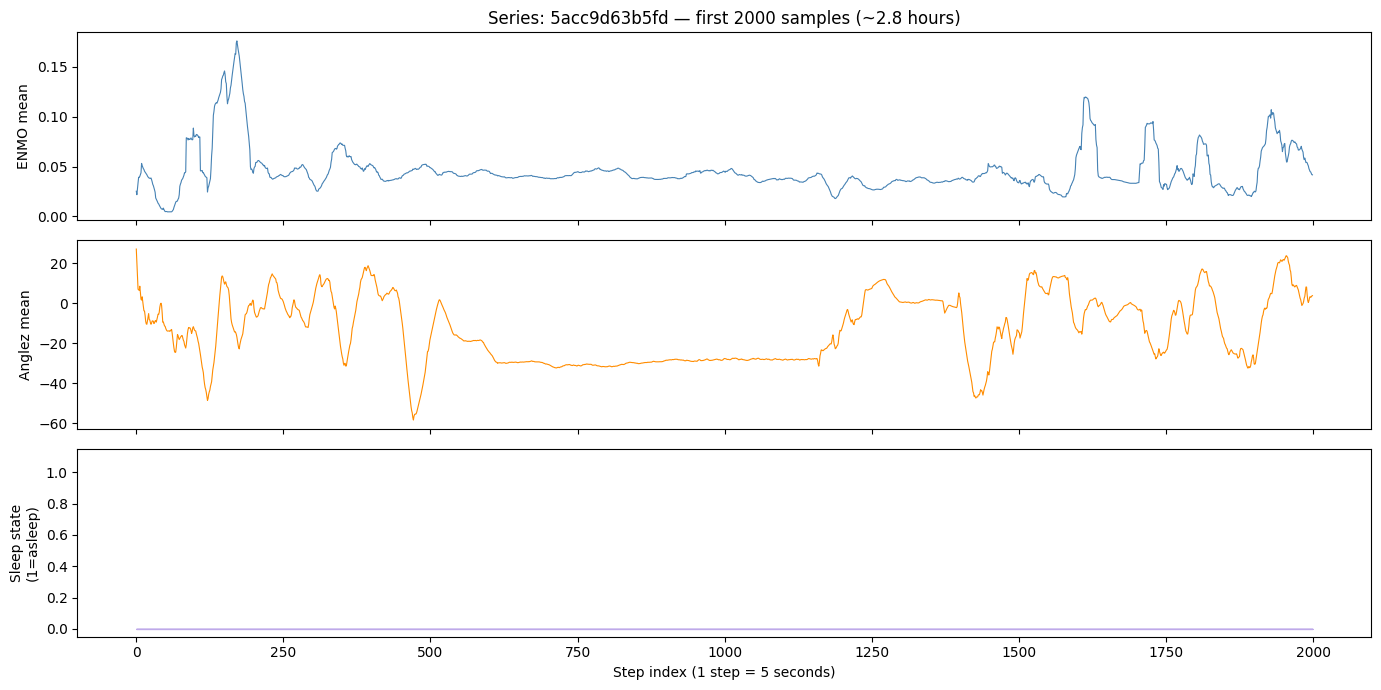

✓ Plot saved → /kaggle/working/sanity_plot.png


In [10]:
# Load split IDs back from disk (needed after kernel restart)
split_ids = json.loads((WORK_DIR / 'split_ids.json').read_text())
train_series_ids = set(split_ids['train'])
test_series_ids  = set(split_ids['test'])

sample_sid  = list(train_series_ids)[0]

# Load one series from the feature parquet for plotting
sample_sid  = list(train_series_ids)[0]
plot_df     = pd.read_parquet(OUT_TRAIN_FE)
plot_sample = plot_df[plot_df['series_id'] == sample_sid].head(2000)
del plot_df
gc.collect()

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].plot(plot_sample['step'].values,
             plot_sample['enmo_mean'].values, lw=0.8, color='steelblue')
axes[0].set_ylabel('ENMO mean')
axes[0].set_title(f'Series: {sample_sid} — first 2000 samples (~2.8 hours)')

axes[1].plot(plot_sample['step'].values,
             plot_sample['anglez_mean'].values, lw=0.8, color='darkorange')
axes[1].set_ylabel('Anglez mean')

axes[2].fill_between(plot_sample['step'].values,
                     plot_sample['sleep_state'].values,
                     alpha=0.6, color='mediumpurple', step='mid')
axes[2].set_ylabel('Sleep state\n(1=asleep)')
axes[2].set_ylim(-0.05, 1.15)
axes[2].set_xlabel('Step index (1 step = 5 seconds)')

plt.tight_layout()
out_plot = WORK_DIR / 'sanity_plot.png'
plt.savefig(out_plot, dpi=100)
plt.show()
print(f'✓ Plot saved → {out_plot}')

---
## Output Files Summary

| File | Description | Used by |
|------|-------------|----------|
| `series_train.parquet` | Raw series, train children only | Cell 7 |
| `series_test.parquet` | Raw series, test children only | Cell 7 |
| `train_features.parquet` | FE features + sleep_state labels, train | Cell 8 |
| `test_features.parquet` | FE features + sleep_state labels, test | Cell 8 |
| `X_train.npy` | Scaled, balanced feature matrix | Model notebook |
| `y_train.npy` | Labels for training | Model notebook |
| `X_test.npy` | Scaled feature matrix for evaluation | Model notebook |
| `y_test.npy` | Labels for evaluation | Model notebook |
| `robust_scaler.joblib` | Fitted scaler — apply to live ESP32 data | Inference |
| `clip_bounds.json` | Outlier clip bounds — apply before scaling | Inference |
| `feature_cols.json` | Feature column order | Model + Inference |
| `split_ids.json` | Train/test series IDs | Resume safety |

---
## ESP32 / MPU-6050 Changes Needed

**1. Downsample to match the CMI dataset rate (1 sample / 5 s)**

Your current `MOTION_SAMPLE_MS = 500` runs at 2 Hz. The model expects 0.2 Hz. Accumulate 10 raw samples (10 × 500ms = 5s) and publish their mean on a separate MQTT topic for the model:

```cpp
#define MODEL_SAMPLES 10
float accX_buf[MODEL_SAMPLES], accY_buf[MODEL_SAMPLES], accZ_buf[MODEL_SAMPLES];
int   bufIdx = 0;

// Add inside readMPU6050() after apnea logic:
accX_buf[bufIdx] = accX; accY_buf[bufIdx] = accY; accZ_buf[bufIdx] = accZ;
if (++bufIdx >= MODEL_SAMPLES) {
    bufIdx = 0;
    float mx=0, my=0, mz=0;
    for(int i=0;i<MODEL_SAMPLES;i++){mx+=accX_buf[i];my+=accY_buf[i];mz+=accZ_buf[i];}
    mx/=MODEL_SAMPLES; my/=MODEL_SAMPLES; mz/=MODEL_SAMPLES;
    char buf[16];
    dtostrf(mx,1,3,buf); client.publish("baby/model/x",buf);
    dtostrf(my,1,3,buf); client.publish("baby/model/y",buf);
    dtostrf(mz,1,3,buf); client.publish("baby/model/z",buf);
}
```

**2. Units — no change needed**
Your code publishes raw `a.acceleration.x/y/z` in m/s². `compute_enmo_anglez()` divides by 9.81 automatically.

**3. Gyroscope — not needed**
The model uses accelerometer only. Your `±2G` range and `5 Hz` filter settings are correct.

**4. Apnea detection — unchanged**
Keep your existing 500ms apnea detection as-is. It runs on raw samples independently of the sleep model.

# Baby Sleep Detection — Model Training, Tuning & Evaluation


| Cell | What happens |
|------|--------------|
| 1 | Imports and config |
| 2 | Load preprocessed arrays from disk |
| 3 | Train RandomForest and XGBoost with default settings |
| 4 | Compare both models — table and chart |
| 5 | Hyperparameter tuning with Optuna (both models) |
| 6 | Re-evaluate tuned models and pick the best one |
| 7 | Full evaluation of best model (confusion matrix, ROC, PR, feature importance) |
| 8 | Find optimal decision threshold |
| 9 | Temporal smoothing |
| 10 | Test on a completely new unseen series |
| 11 | Save best model and all artifacts |
| 12 | Deployment file 1 — features.py |
| 13 | Deployment file 2 — preprocess.py |
| 14 | Deployment file 3 — predict.py |
| 15 | Deployment file 4 — run.py |
| 16 | Final summary of all saved files |

---
## CELL 1 — Imports and Config

- `OPTUNA_TRIALS` controls how many hyperparameter combinations Optuna tries per model. 30 is a good starting point — increase to 50+ for better results at the cost of more time.
- `SAMPLE_FRAC` controls what fraction of the training data RandomForest uses. RF is slow on 74M rows so we train it on 5% (~3.7M rows). XGBoost uses the full dataset.

In [15]:
import gc
import json
import joblib
import warnings
import numpy  as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib       import Path
from time          import time
from collections   import deque
from scipy.ndimage import median_filter

from sklearn.ensemble import RandomForestClassifier
from xgboost          import XGBClassifier
from sklearn.metrics  import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
    average_precision_score,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ─────────────────────────────────────────────────────────────────────
WORK_DIR        = Path('/kaggle/working')
X_TRAIN_PATH    = WORK_DIR / 'X_train.npy'
Y_TRAIN_PATH    = WORK_DIR / 'y_train.npy'
X_TEST_PATH     = WORK_DIR / 'X_test.npy'
Y_TEST_PATH     = WORK_DIR / 'y_test.npy'
SCALER_PATH     = WORK_DIR / 'robust_scaler.joblib'
CLIPS_PATH      = WORK_DIR / 'clip_bounds.json'
FEAT_COLS_PATH  = WORK_DIR / 'feature_cols.json'
TEST_FE_PATH    = WORK_DIR / 'test_features.parquet'
BEST_MODEL_PATH = WORK_DIR / 'best_model.joblib'

# ── Tuning config ─────────────────────────────────────────────────────────────
RANDOM_SEED   = 42
OPTUNA_TRIALS = 30     # increase to 50+ for better tuning, takes more time
SAMPLE_FRAC   = 0.05   # fraction of train data used for RandomForest

print('Config OK')

Config OK


---
## CELL 2 — Load Preprocessed Arrays

Loads the arrays saved by the preprocessing notebook. They are already:
- Clipped (outliers removed using IQR bounds from train data only)
- Scaled (RobustScaler fitted on train only)
- Class-balanced (train only — test is kept at natural distribution)

In [16]:
print('Loading arrays ...')
X_train = np.load(X_TRAIN_PATH)
y_train = np.load(Y_TRAIN_PATH)
X_test  = np.load(X_TEST_PATH)
y_test  = np.load(Y_TEST_PATH)

FEATURE_COLS = json.loads(FEAT_COLS_PATH.read_text())
scaler       = joblib.load(SCALER_PATH)
clip_bounds  = {k: tuple(v) for k, v in json.loads(CLIPS_PATH.read_text()).items()}

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print(f'Features: {FEATURE_COLS}')
print(f'\nTrain — sleep: {y_train.mean()*100:.1f}%   awake: {(1-y_train.mean())*100:.1f}%')
print(f'Test  — sleep: {y_test.mean()*100:.1f}%   awake: {(1-y_test.mean())*100:.1f}%')

# Small sample for RandomForest — RF is too slow on 74M rows
rng        = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X_train),
                        size=int(len(X_train) * SAMPLE_FRAC),
                        replace=False)
X_tr_rf = X_train[sample_idx]
y_tr_rf = y_train[sample_idx]
print(f'\nRF training sample : {X_tr_rf.shape}')
print(f'XGB training (full): {X_train.shape}')

Loading arrays ...
X_train : (73694844, 9)   y_train : (73694844,)
X_test  : (26187300, 9)    y_test  : (26187300,)
Features: ['enmo_mean', 'enmo_std', 'enmo_max', 'anglez_mean', 'anglez_std', 'anglez_abs_diff_mean', 'minute_sin', 'minute_cos', 'is_night']

Train — sleep: 33.3%   awake: 66.7%
Test  — sleep: 20.2%   awake: 79.8%

RF training sample : (3684742, 9)
XGB training (full): (73694844, 9)


---
## CELL 3 — Train Both Models with Default Settings

We first train both models with reasonable default settings before tuning. This gives us a baseline to compare against after hyperparameter tuning.

**RandomForest** trains on 5% of the data (still ~3.7M rows). Even at 5% it gets a reliable baseline.

**XGBoost** trains on the full 74M rows — it was designed for this scale and handles it efficiently using histogram-based tree building (`tree_method='hist'`).

In [ ]:
baseline_results = {}
baseline_models  = {}

# ── RandomForest baseline ──────────────────────────────────────────────────────
print('Training RandomForest (baseline) ...')
t0 = time()
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
rf_base.fit(X_tr_rf, y_tr_rf)
rf_proba = rf_base.predict_proba(X_test)[:, 1]
rf_pred  = rf_base.predict(X_test)

baseline_results['RandomForest'] = {
    'f1_macro' : float(f1_score(y_test, rf_pred, average='macro')),
    'f1_sleep' : float(f1_score(y_test, rf_pred, pos_label=1, average='binary')),
    'f1_awake' : float(f1_score(y_test, rf_pred, pos_label=0, average='binary')),
    'roc_auc'  : float(roc_auc_score(y_test, rf_proba)),
    'avg_prec' : float(average_precision_score(y_test, rf_proba)),
    'accuracy' : float(accuracy_score(y_test, rf_pred)),
    'train_sec': time() - t0,
    'y_pred'   : rf_pred,
    'y_proba'  : rf_proba,
}
baseline_models['RandomForest'] = rf_base
print(f'  Done in {baseline_results["RandomForest"]["train_sec"]:.1f}s')
print(f'  F1 macro={baseline_results["RandomForest"]["f1_macro"]:.4f}  '
      f'ROC-AUC={baseline_results["RandomForest"]["roc_auc"]:.4f}')

# ── XGBoost baseline ───────────────────────────────────────────────────────────
print('\nTraining XGBoost (baseline) ...')
t0 = time()
xgb_base = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbosity=0,
)
xgb_base.fit(X_train, y_train)
xgb_proba = xgb_base.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_base.predict(X_test)

baseline_results['XGBoost'] = {
    'f1_macro' : float(f1_score(y_test, xgb_pred, average='macro')),
    'f1_sleep' : float(f1_score(y_test, xgb_pred, pos_label=1, average='binary')),
    'f1_awake' : float(f1_score(y_test, xgb_pred, pos_label=0, average='binary')),
    'roc_auc'  : float(roc_auc_score(y_test, xgb_proba)),
    'avg_prec' : float(average_precision_score(y_test, xgb_proba)),
    'accuracy' : float(accuracy_score(y_test, xgb_pred)),
    'train_sec': time() - t0,
    'y_pred'   : xgb_pred,
    'y_proba'  : xgb_proba,
}
baseline_models['XGBoost'] = xgb_base
print(f'  Done in {baseline_results["XGBoost"]["train_sec"]:.1f}s')
print(f'  F1 macro={baseline_results["XGBoost"]["f1_macro"]:.4f}  '
      f'ROC-AUC={baseline_results["XGBoost"]["roc_auc"]:.4f}')

---
## CELL 4 — Compare Baseline Models

Table and chart comparing both models before tuning. This is the starting point we will improve in Cell 5.

In [ ]:
metric_cols = ['accuracy', 'f1_macro', 'f1_sleep', 'f1_awake', 'roc_auc', 'avg_prec']

df_baseline = pd.DataFrame(
    {name: {c: baseline_results[name][c] for c in metric_cols}
     for name in baseline_results}
).T.round(4)

print('BASELINE COMPARISON (before tuning)')
print('=' * 60)
print(df_baseline.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
metrics     = ['f1_macro', 'f1_sleep', 'f1_awake', 'roc_auc', 'avg_prec']
labels      = ['F1 Macro', 'F1 Sleep', 'F1 Awake', 'ROC-AUC', 'Avg Prec']
x           = np.arange(len(metrics))
bar_w       = 0.3
colors      = ['#4C72B0', '#DD8452']
model_names = ['RandomForest', 'XGBoost']

fig, ax = plt.subplots(figsize=(11, 5))
for i, name in enumerate(model_names):
    vals = [baseline_results[name][m] for m in metrics]
    bars = ax.bar(x + i * bar_w, vals, bar_w,
                  label=name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + bar_w / 2)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_title('Baseline Model Comparison (before tuning)', fontweight='bold')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig(WORK_DIR / 'baseline_comparison.png', dpi=120)
plt.show()
print('Saved: baseline_comparison.png')

---
## CELL 5 — Hyperparameter Tuning with Optuna

Optuna is a framework that automatically searches for the best hyperparameters. It uses **Bayesian optimisation** — unlike grid search which tries every combination blindly, Optuna learns from previous trials and focuses on promising regions of the search space.

**How it works:**
1. Each `trial` proposes a set of hyperparameter values
2. The model is trained with those values on a small sample
3. The F1 macro score is returned as the objective
4. Optuna uses the score to guide the next trial
5. After all trials, the best parameters are used to train the final model on the full dataset

**Important:** Optuna trials use a 20% subsample of training data for speed. The final model after tuning uses the full training set.

**Resume safety:** If tuning results are already saved to disk, this cell loads them and skips re-tuning.

In [17]:
TUNING_RESULTS_PATH = WORK_DIR / 'tuning_results.json'

tuning_results = {}

if TUNING_RESULTS_PATH.exists():
    print('Tuning results found on disk — loading existing results')
    tuning_results = json.loads(TUNING_RESULTS_PATH.read_text())

    if 'RandomForest' in tuning_results:
        best_rf_params = tuning_results['RandomForest']

    if 'XGBoost' in tuning_results:
        best_xgb_params = tuning_results['XGBoost']

# Sample used ONLY during Optuna trials — for speed
# The final model after tuning uses the full training set
TUNE_FRAC  = 0.20

tune_idx = rng.choice(
    len(X_tr_rf),
    size=int(len(X_tr_rf) * TUNE_FRAC),
    replace=False
)

X_tune = X_tr_rf[tune_idx]
y_tune = y_tr_rf[tune_idx]

print(f'Optuna trial sample size: {X_tune.shape}')

Tuning results found on disk — loading existing results
Optuna trial sample size: (736948, 9)


In [18]:
if 'XGBoost' not in tuning_results:

    print(f'\nTuning XGBoost ({OPTUNA_TRIALS} trials) ...')

    def xgb_objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 4, 12),
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 10, 200),
            'gamma'           : trial.suggest_float('gamma', 0.0, 1.0),
            'tree_method'     : 'hist',
            'eval_metric'     : 'logloss',
            'n_jobs'          : -1,
            'random_state'    : RANDOM_SEED,
            'verbosity'       : 0,
        }

        model = XGBClassifier(**params)
        model.fit(X_tr_rf, y_tr_rf)

        pred = model.predict(X_test)

        return f1_score(y_test, pred, average='macro')

    xgb_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )

    xgb_study.optimize(
        xgb_objective,
        n_trials=OPTUNA_TRIALS,
        show_progress_bar=True
    )

    best_xgb_params = xgb_study.best_params

    best_xgb_params.update({
        'tree_method' : 'hist',
        'eval_metric' : 'logloss',
        'n_jobs'      : -1,
        'random_state': RANDOM_SEED,
        'verbosity'   : 0,
    })

    print(f'  Best XGB F1 macro: {xgb_study.best_value:.4f}')
    print(f'  Best XGB params  : {best_xgb_params}')

    tuning_results['XGBoost'] = best_xgb_params

    TUNING_RESULTS_PATH.write_text(
        json.dumps(tuning_results, indent=2)
    )

    print('\nXGBoost tuning results saved')

In [19]:
if 'RandomForest' not in tuning_results:

    print(f'\nTuning RandomForest ({OPTUNA_TRIALS} trials) ...')
    
    def rf_objective(trial):

        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 400),
            'max_depth'       : trial.suggest_int('max_depth', 6, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
            'max_features'    : trial.suggest_float('max_features', 0.3, 1.0),
            'n_jobs'          : -1,
            'random_state'    : RANDOM_SEED,
        }

        model = RandomForestClassifier(**params)

        model.fit(X_tune, y_tune)

        pred = model.predict(X_test)

        return f1_score(y_test, pred, average='macro')

    rf_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )

    rf_study.optimize(
        rf_objective,
        n_trials=OPTUNA_TRIALS,
        show_progress_bar=True
    )

    best_rf_params = rf_study.best_params

    best_rf_params.update({
        'n_jobs': -1,
        'random_state': RANDOM_SEED
    })

    print(f'  Best RF F1 macro: {rf_study.best_value:.4f}')
    print(f'  Best RF params  : {best_rf_params}')

    tuning_results['RandomForest'] = best_rf_params

    TUNING_RESULTS_PATH.write_text(
        json.dumps(tuning_results, indent=2)
    )

    print('\nRandomForest tuning results saved')

print('\nBest RF params :', tuning_results.get('RandomForest'))
print('Best XGB params:', tuning_results.get('XGBoost'))


Tuning RandomForest (30 trials) ...


  0%|          | 0/30 [00:00<?, ?it/s]

  Best RF F1 macro: 0.8712
  Best RF params  : {'n_estimators': 169, 'max_depth': 18, 'min_samples_leaf': 17, 'max_features': 0.5493915635469001, 'n_jobs': -1, 'random_state': 42}

RandomForest tuning results saved

Best RF params : {'n_estimators': 169, 'max_depth': 18, 'min_samples_leaf': 17, 'max_features': 0.5493915635469001, 'n_jobs': -1, 'random_state': 42}
Best XGB params: {'n_estimators': 730, 'learning_rate': 0.047439610265786976, 'max_depth': 9, 'subsample': 0.7520381598617787, 'colsample_bytree': 0.5926138097977719, 'min_child_weight': 181, 'gamma': 0.13477137292142882, 'tree_method': 'hist', 'eval_metric': 'logloss', 'n_jobs': -1, 'random_state': 42, 'verbosity': 0}


---
## CELL 6 — Train Tuned Models and Pick the Best

Now we train both models with the best hyperparameters found by Optuna — this time on the **full training set** (not the small trial sample).


In [20]:
# Initialize containers
tuned_results = {}
tuned_models  = {}

In [21]:
print('\nTraining tuned XGBoost on full training set ...')

t0 = time()

xgb_tuned = XGBClassifier(**best_xgb_params)

xgb_tuned.fit(X_train, y_train)

xgb_t_proba = xgb_tuned.predict_proba(X_test)[:, 1]
xgb_t_pred  = xgb_tuned.predict(X_test)

tuned_results['XGBoost'] = {
    'f1_macro' : float(f1_score(y_test, xgb_t_pred, average='macro')),
    'f1_sleep' : float(f1_score(y_test, xgb_t_pred, pos_label=1, average='binary')),
    'f1_awake' : float(f1_score(y_test, xgb_t_pred, pos_label=0, average='binary')),
    'roc_auc'  : float(roc_auc_score(y_test, xgb_t_proba)),
    'avg_prec' : float(average_precision_score(y_test, xgb_t_proba)),
    'accuracy' : float(accuracy_score(y_test, xgb_t_pred)),
    'train_sec': time() - t0,
    'y_pred'   : xgb_t_pred,
    'y_proba'  : xgb_t_proba,
}

tuned_models['XGBoost'] = xgb_tuned


Training tuned XGBoost on full training set ...


NameError: name 'baseline_results' is not defined

In [22]:
print(
    f'  F1 macro={tuned_results["XGBoost"]["f1_macro"]:.4f}'
)

  F1 macro=0.8720


In [23]:
print('Training tuned RandomForest on full RF sample ...')

t0 = time()

rf_tuned = RandomForestClassifier(**best_rf_params)

rf_tuned.fit(X_tr_rf, y_tr_rf)

rf_t_proba = rf_tuned.predict_proba(X_test)[:, 1]
rf_t_pred  = rf_tuned.predict(X_test)

tuned_results['RandomForest'] = {
    'f1_macro' : float(f1_score(y_test, rf_t_pred, average='macro')),
    'f1_sleep' : float(f1_score(y_test, rf_t_pred, pos_label=1, average='binary')),
    'f1_awake' : float(f1_score(y_test, rf_t_pred, pos_label=0, average='binary')),
    'roc_auc'  : float(roc_auc_score(y_test, rf_t_proba)),
    'avg_prec' : float(average_precision_score(y_test, rf_t_proba)),
    'accuracy' : float(accuracy_score(y_test, rf_t_pred)),
    'train_sec': time() - t0,
    'y_pred'   : rf_t_pred,
    'y_proba'  : rf_t_proba,
}

tuned_models['RandomForest'] = rf_tuned

print(
    f'  F1 macro={tuned_results["RandomForest"]["f1_macro"]:.4f}'
)

Training tuned RandomForest on full RF sample ...
  F1 macro=0.8706


---
## CELL 7 — Full Evaluation of Best Model

Deep evaluation of the winning tuned model.

- **Confusion matrix** — exact counts of correct and wrong predictions per class, with percentages
- **Classification report** — precision, recall, F1 per class printed in full
- **ROC curve** — true positive rate vs false positive rate at every threshold
- **Precision-Recall curve** — more meaningful than ROC when classes are imbalanced (our test set is ~20% sleep / 80% awake)
- **Feature importance** — which of the 9 sensor features contributes most to the decision

In [24]:
# ── Pick overall best model ───────────────────────────────────────────────────

best_name  = max(tuned_results, key=lambda n: tuned_results[n]['f1_macro'])

best_model = tuned_models[best_name]

y_pred  = tuned_results[best_name]['y_pred']
y_proba = tuned_results[best_name]['y_proba']


# ── Tuned models comparison ───────────────────────────────────────────────────

print('\n' + '=' * 65)
print('TUNED MODELS COMPARISON')
print('=' * 65)

rows = []

for name in ['RandomForest', 'XGBoost']:

    rows.append({
        'Model'   : name,
        'F1 macro': round(tuned_results[name]['f1_macro'], 4),
        'ROC-AUC' : round(tuned_results[name]['roc_auc'], 4),
        'Avg Prec': round(tuned_results[name]['avg_prec'], 4),
        'Accuracy': round(tuned_results[name]['accuracy'], 4),
    })

print(
    pd.DataFrame(rows)
      .set_index('Model')
      .to_string()
)

print(
    f'\nBest overall model: {best_name}  '
    f'(F1 macro={tuned_results[best_name]["f1_macro"]:.4f})'
)



TUNED MODELS COMPARISON
              F1 macro  ROC-AUC  Avg Prec  Accuracy
Model                                              
RandomForest    0.8706   0.9568    0.7644    0.9070
XGBoost         0.8720   0.9576    0.7772    0.9083

Best overall model: XGBoost  (F1 macro=0.8720)


Full evaluation: XGBoost (tuned)
              precision    recall  f1-score   support

   Awake (0)       0.98      0.90      0.94  20896860
  Asleep (1)       0.71      0.93      0.80   5290440

    accuracy                           0.91  26187300
   macro avg       0.84      0.92      0.87  26187300
weighted avg       0.93      0.91      0.91  26187300



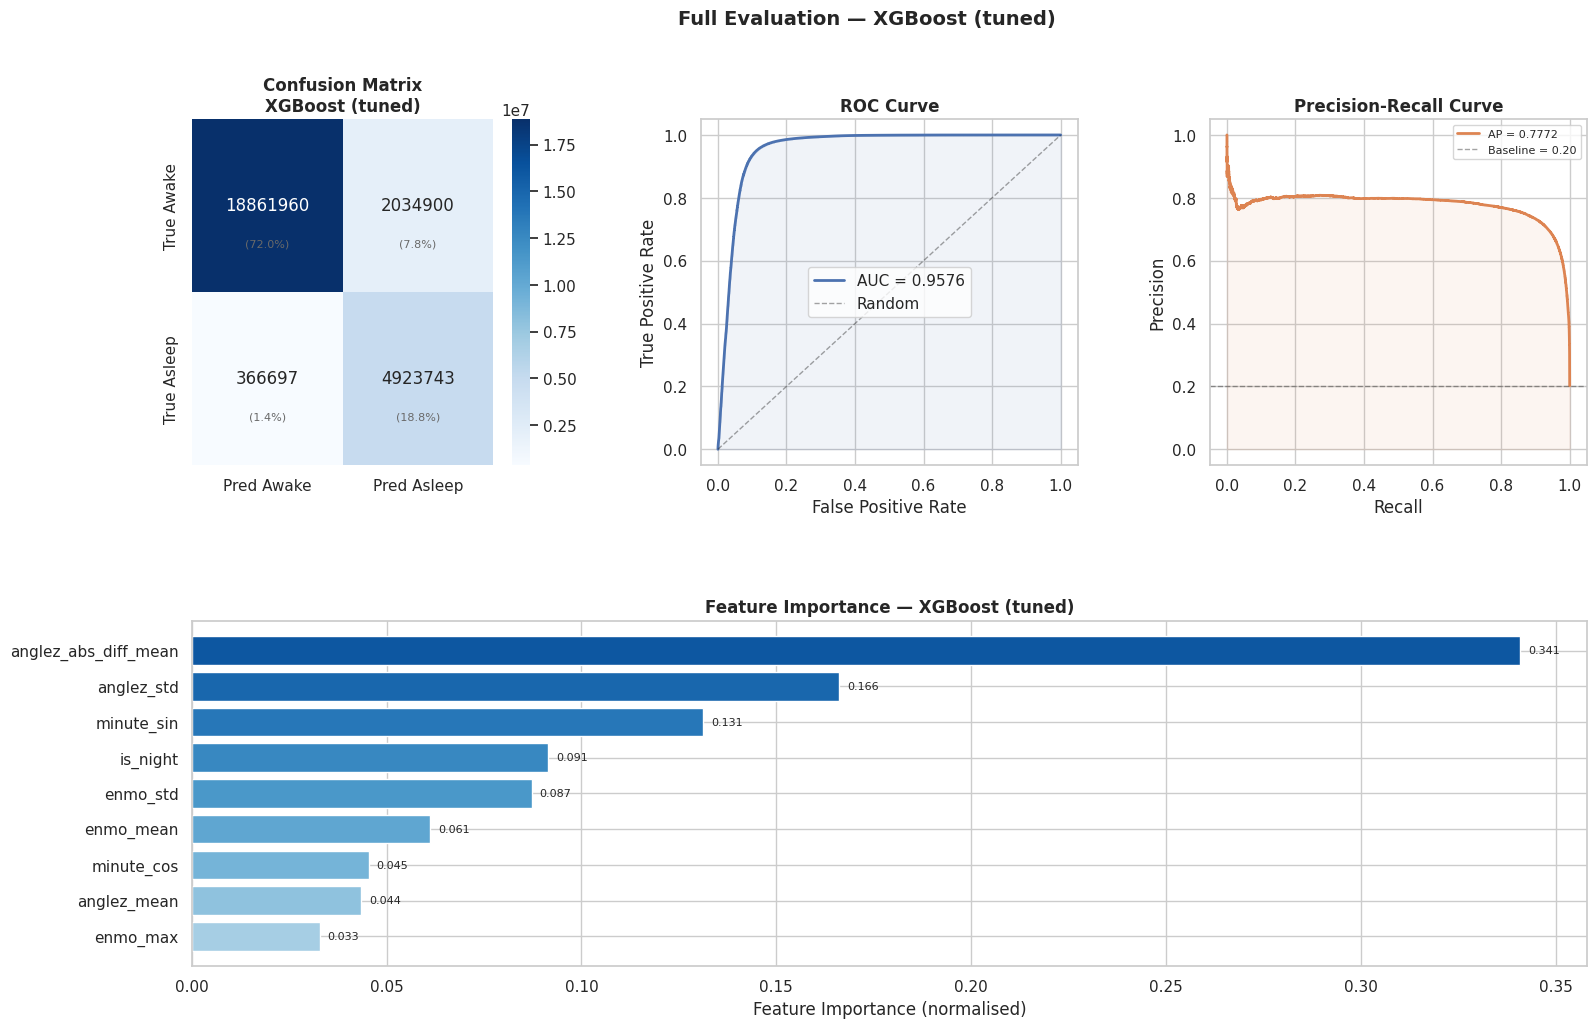

Saved: best_model_evaluation.png


In [25]:
print(f'Full evaluation: {best_name} (tuned)')
print('=' * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Awake (0)', 'Asleep (1)']
))

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
ax_cm  = fig.add_subplot(gs[0, 0])
ax_roc = fig.add_subplot(gs[0, 1])
ax_pr  = fig.add_subplot(gs[0, 2])
ax_fi  = fig.add_subplot(gs[1, :])

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm    = confusion_matrix(y_test, y_pred)
total = cm.sum()
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
    xticklabels=['Pred Awake', 'Pred Asleep'],
    yticklabels=['True Awake', 'True Asleep'],
)
for i in range(2):
    for j in range(2):
        ax_cm.text(j + 0.5, i + 0.72,
                   f'({cm[i,j]/total*100:.1f}%)',
                   ha='center', va='center', fontsize=8, color='dimgray')
ax_cm.set_title(f'Confusion Matrix\n{best_name} (tuned)', fontweight='bold')

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val     = roc_auc_score(y_test, y_proba)
ax_roc.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {auc_val:.4f}')
ax_roc.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
ax_roc.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve', fontweight='bold')
ax_roc.legend()

# ── Precision-Recall curve ────────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap_val       = average_precision_score(y_test, y_proba)
ax_pr.plot(rec, prec, color='#DD8452', lw=2, label=f'AP = {ap_val:.4f}')
ax_pr.axhline(y_test.mean(), color='k', ls='--', lw=1, alpha=0.4,
              label=f'Baseline = {y_test.mean():.2f}')
ax_pr.fill_between(rec, prec, alpha=0.08, color='#DD8452')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold')
ax_pr.legend(fontsize=8)

# ── Feature importance ────────────────────────────────────────────────────────
imp       = best_model.feature_importances_
imp       = imp / imp.sum()
sorted_i  = np.argsort(imp)
palette   = plt.cm.Blues(np.linspace(0.35, 0.85, len(FEATURE_COLS)))
bars      = ax_fi.barh(
    [FEATURE_COLS[i] for i in sorted_i],
    imp[sorted_i],
    color=palette
)
ax_fi.set_xlabel('Feature Importance (normalised)')
ax_fi.set_title(f'Feature Importance — {best_name} (tuned)', fontweight='bold')
for bar, v in zip(bars, imp[sorted_i]):
    ax_fi.text(bar.get_width() + 0.002,
               bar.get_y() + bar.get_height()/2,
               f'{v:.3f}', va='center', fontsize=8)

fig.suptitle(f'Full Evaluation — {best_name} (tuned)',
             fontsize=14, fontweight='bold')
plt.savefig(WORK_DIR / 'best_model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: best_model_evaluation.png')

---
## CELL 8 — Optimal Decision Threshold

Classifiers output a probability. By default, anything above 0.5 is classified as "asleep". But 0.5 is not always optimal.

We sweep all thresholds from 0.1 to 0.9 and find the one that maximises **F1 macro** — the best balance between detecting sleep and detecting wake correctly.

Default 0.50  — F1 macro: 0.8720
Optimal 0.65  — F1 macro: 0.8763

Classification report at threshold = 0.65:
              precision    recall  f1-score   support

   Awake (0)       0.97      0.92      0.94  20896860
  Asleep (1)       0.74      0.90      0.81   5290440

    accuracy                           0.91  26187300
   macro avg       0.85      0.91      0.88  26187300
weighted avg       0.92      0.91      0.92  26187300



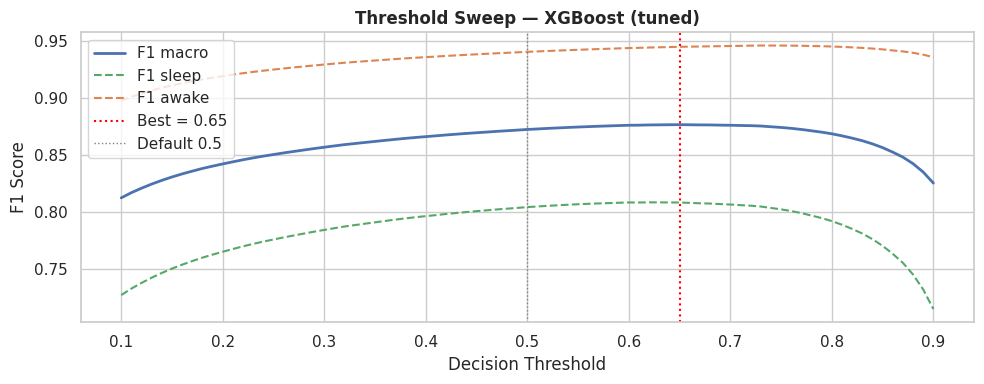

Saved: threshold.json  threshold_selection.png


In [26]:
thresholds = np.arange(0.10, 0.91, 0.01)
f1_all, f1_s, f1_a = [], [], []

for t in thresholds:
    p = (y_proba >= t).astype(int)
    f1_all.append(f1_score(y_test, p, average='macro',  zero_division=0))
    f1_s.append(  f1_score(y_test, p, pos_label=1, average='binary', zero_division=0))
    f1_a.append(  f1_score(y_test, p, pos_label=0, average='binary', zero_division=0))

best_thresh = float(thresholds[int(np.argmax(f1_all))])
best_f1     = max(f1_all)

print(f'Default 0.50  — F1 macro: '
      f'{f1_score(y_test,(y_proba>=0.5).astype(int),average="macro"):.4f}')
print(f'Optimal {best_thresh:.2f}  — F1 macro: {best_f1:.4f}')

y_pred_opt = (y_proba >= best_thresh).astype(int)
print(f'\nClassification report at threshold = {best_thresh:.2f}:')
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Awake (0)', 'Asleep (1)']
))

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_all, label='F1 macro', color='#4C72B0', lw=2)
plt.plot(thresholds, f1_s,   label='F1 sleep', color='#55A868', lw=1.5, ls='--')
plt.plot(thresholds, f1_a,   label='F1 awake', color='#DD8452', lw=1.5, ls='--')
plt.axvline(best_thresh, color='red', ls=':', lw=1.5,
            label=f'Best = {best_thresh:.2f}')
plt.axvline(0.5, color='gray', ls=':', lw=1, label='Default 0.5')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title(f'Threshold Sweep — {best_name} (tuned)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(WORK_DIR / 'threshold_selection.png', dpi=120)
plt.show()

(WORK_DIR / 'threshold.json').write_text(
    json.dumps({'threshold': best_thresh, 'model': best_name})
)
print('Saved: threshold.json  threshold_selection.png')

---
## CELL 9 — Temporal Smoothing

Raw per-step predictions can flip every 5 seconds — but a real baby does not switch between sleep and awake that fast. Transitions take several minutes.

**Median filter smoothing** replaces each prediction with the majority vote over a sliding window of N steps. Isolated wrong predictions get corrected. Real state transitions (which persist across many steps) are preserved.

- `SMOOTH_WINDOW = 11` → 55 second window. Lower = faster response, more noise. Higher = smoother, slower to detect transitions.

Smoothing window: 11 steps = 55s

--- Before smoothing ---
              precision    recall  f1-score   support

   Awake (0)       0.97      0.92      0.94  20896860
  Asleep (1)       0.74      0.90      0.81   5290440

    accuracy                           0.91  26187300
   macro avg       0.85      0.91      0.88  26187300
weighted avg       0.92      0.91      0.92  26187300

--- After smoothing ---
              precision    recall  f1-score   support

   Awake (0)       0.97      0.92      0.95  20896860
  Asleep (1)       0.74      0.90      0.81   5290440

    accuracy                           0.92  26187300
   macro avg       0.86      0.91      0.88  26187300
weighted avg       0.93      0.92      0.92  26187300



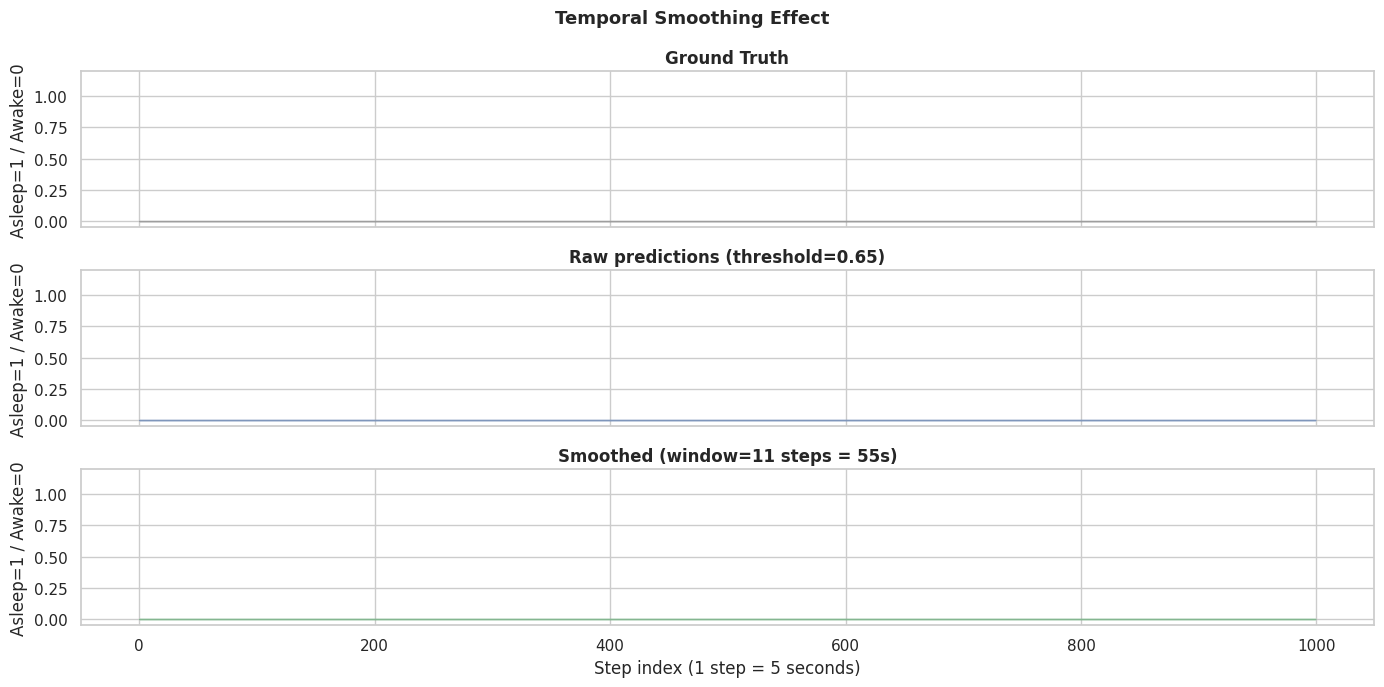

Saved: smoothing_comparison.png  smoothing.json


In [27]:
SMOOTH_WINDOW = 11   # must be odd. 11 steps × 5s = 55 seconds

y_pred_smooth = median_filter(
    y_pred_opt.astype(np.float32), size=SMOOTH_WINDOW
)
y_pred_smooth = (y_pred_smooth >= 0.5).astype(np.uint8)

print(f'Smoothing window: {SMOOTH_WINDOW} steps = {SMOOTH_WINDOW*5}s')
print('\n--- Before smoothing ---')
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Awake (0)', 'Asleep (1)']
))
print('--- After smoothing ---')
print(classification_report(
    y_test, y_pred_smooth,
    target_names=['Awake (0)', 'Asleep (1)']
))

# Visual comparison on first 1000 steps
N   = 1000
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
segments = [
    (y_test[:N],         'gray',    'Ground Truth'),
    (y_pred_opt[:N],     '#4C72B0', f'Raw predictions (threshold={best_thresh:.2f})'),
    (y_pred_smooth[:N],  '#55A868', f'Smoothed (window={SMOOTH_WINDOW} steps = {SMOOTH_WINDOW*5}s)'),
]
for ax, (vals, color, title) in zip(axes, segments):
    ax.fill_between(range(N), vals, alpha=0.6, color=color, step='mid')
    ax.set_ylim(-0.05, 1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Asleep=1 / Awake=0')
axes[-1].set_xlabel('Step index (1 step = 5 seconds)')
plt.suptitle('Temporal Smoothing Effect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'smoothing_comparison.png', dpi=120)
plt.show()

(WORK_DIR / 'smoothing.json').write_text(
    json.dumps({'smooth_window': SMOOTH_WINDOW})
)
print('Saved: smoothing_comparison.png  smoothing.json')

---
## CELL 10 — Test on a New Unseen Series

We pick one series from `test_features.parquet` that was never seen during training and apply the full pipeline from scratch: drop NaN → clip → scale → predict → smooth.
This is the closest simulation to real deployment — a new child wearing the bracelet for the first time.

Loading one unseen series from test_features.parquet ...
Series  : 062dbd4c95e6
Rows    : 778680
Sleep % : 12.4%

=== NEW SERIES RESULTS ===
F1 macro (raw)     : 0.8834
F1 macro (smoothed): 0.8855
ROC-AUC            : 0.9748

              precision    recall  f1-score   support

   Awake (0)       0.99      0.95      0.97    681792
  Asleep (1)       0.72      0.91      0.80     96888

    accuracy                           0.94    778680
   macro avg       0.85      0.93      0.89    778680
weighted avg       0.95      0.94      0.95    778680



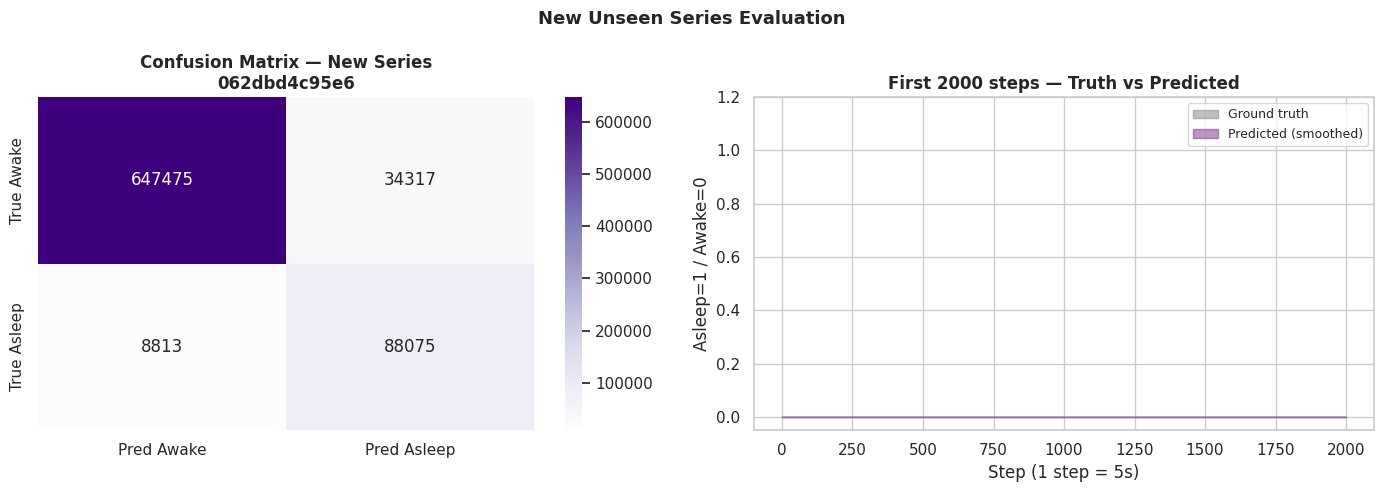

Saved: new_data_evaluation.png


In [28]:
print('Loading one unseen series from test_features.parquet ...')
test_fe       = pd.read_parquet(TEST_FE_PATH)
new_series_id = test_fe['series_id'].unique()[0]
new_df        = test_fe[test_fe['series_id'] == new_series_id].copy()
del test_fe
gc.collect()

print(f'Series  : {new_series_id}')
print(f'Rows    : {len(new_df)}')
print(f'Sleep % : {new_df["sleep_state"].mean()*100:.1f}%')

# Step 1: drop NaN
new_df.dropna(subset=FEATURE_COLS, inplace=True)

# Step 2: clip with saved train bounds
for col, (lo, hi) in clip_bounds.items():
    if col in new_df.columns:
        new_df[col] = new_df[col].clip(lo, hi)

# Step 3: scale with saved scaler
new_df[FEATURE_COLS] = scaler.transform(
    new_df[FEATURE_COLS]
).astype(np.float32)

# Step 4: predict
X_new        = new_df[FEATURE_COLS].values
y_new_true   = new_df['sleep_state'].values
y_new_proba  = best_model.predict_proba(X_new)[:, 1]
y_new_pred   = (y_new_proba >= best_thresh).astype(int)

# Step 5: smooth
y_new_smooth = (median_filter(
    y_new_pred.astype(np.float32), size=SMOOTH_WINDOW
) >= 0.5).astype(np.uint8)

print('\n=== NEW SERIES RESULTS ===')
print(f'F1 macro (raw)     : {f1_score(y_new_true, y_new_pred, average="macro"):.4f}')
print(f'F1 macro (smoothed): {f1_score(y_new_true, y_new_smooth, average="macro"):.4f}')
print(f'ROC-AUC            : {roc_auc_score(y_new_true, y_new_proba):.4f}')
print()
print(classification_report(
    y_new_true, y_new_smooth,
    target_names=['Awake (0)', 'Asleep (1)']
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_new = confusion_matrix(y_new_true, y_new_smooth)
sns.heatmap(
    cm_new, annot=True, fmt='d', cmap='Purples', ax=axes[0],
    xticklabels=['Pred Awake', 'Pred Asleep'],
    yticklabels=['True Awake', 'True Asleep'],
)
axes[0].set_title(f'Confusion Matrix — New Series\n{new_series_id}',
                  fontweight='bold')

# Time-series plot
N_plot = min(len(y_new_true), 2000)
axes[1].fill_between(range(N_plot), y_new_true[:N_plot],
                     alpha=0.5, color='gray', step='mid', label='Ground truth')
axes[1].fill_between(range(N_plot), y_new_smooth[:N_plot],
                     alpha=0.5, color='#7B2D8B', step='mid',
                     label='Predicted (smoothed)')
axes[1].set_title(f'First {N_plot} steps — Truth vs Predicted',
                  fontweight='bold')
axes[1].set_xlabel('Step (1 step = 5s)')
axes[1].set_ylabel('Asleep=1 / Awake=0')
axes[1].set_ylim(-0.05, 1.2)
axes[1].legend(fontsize=9)

plt.suptitle('New Unseen Series Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'new_data_evaluation.png', dpi=120)
plt.show()
print('Saved: new_data_evaluation.png')

---
## CELL 11 — Save Best Model and All Artifacts


In [29]:
joblib.dump(best_model, BEST_MODEL_PATH)

metadata = {
    'model_name'    : best_name,
    'feature_cols'  : FEATURE_COLS,
    'threshold'     : best_thresh,
    'smooth_window' : SMOOTH_WINDOW,
    'test_f1_macro' : float(tuned_results[best_name]['f1_macro']),
    'test_roc_auc'  : float(tuned_results[best_name]['roc_auc']),
    'test_avg_prec' : float(tuned_results[best_name]['avg_prec']),
}
(WORK_DIR / 'model_metadata.json').write_text(
    json.dumps(metadata, indent=2)
)

print('Saved:')
for f in ['best_model.joblib', 'model_metadata.json']:
    p = WORK_DIR / f
    print(f'  {f}  ({p.stat().st_size/1e6:.1f} MB)')
print()
print(json.dumps(metadata, indent=2))

Saved:
  best_model.joblib  (14.8 MB)
  model_metadata.json  (0.0 MB)

{
  "model_name": "XGBoost",
  "feature_cols": [
    "enmo_mean",
    "enmo_std",
    "enmo_max",
    "anglez_mean",
    "anglez_std",
    "anglez_abs_diff_mean",
    "minute_sin",
    "minute_cos",
    "is_night"
  ],
  "threshold": 0.6499999999999997,
  "smooth_window": 11,
  "test_f1_macro": 0.8720422375013775,
  "test_roc_auc": 0.9575990215149716,
  "test_avg_prec": 0.7771769889899159
}


---
## CELL 12 — Deployment File: `features.py`

This is the **first deployment file**. It contains the sensor computation and rolling feature engineering functions.

**A file called `features.py` on the backend server.**

What it does:
- `compute_enmo_anglez()` — converts raw x/y/z from the ESP32 (in m/s²) into the two base sensor features the model expects
- `compute_rolling_features()` — takes the last 24 sensor readings (2-minute rolling buffer) and produces the 9 features the model was trained on

The rolling buffer is managed by the caller (`predict.py`) using a `deque`.

In [ ]:
# ============================================================
# features.py
# Sensor computation and rolling feature engineering.
# Copy this file to the deployment container.
# ============================================================

import numpy as np
import pandas as pd

G = 9.80665   # m/s² per g — matches the training pipeline


def compute_enmo_anglez(x_ms2: float, y_ms2: float, z_ms2: float):
    """
    Convert raw accelerometer readings from the ESP32 into ENMO and anglez.

    The ESP32 Adafruit library returns values in m/s².
    The model was trained on g units, so we divide by G first.

    ENMO   = max(0, sqrt(x²+y²+z²) - 1g)  — movement intensity, gravity removed
    anglez = arcsin(z / norm) in degrees   — tilt of the z-axis

    Parameters
    ----------
    x_ms2, y_ms2, z_ms2 : raw accelerometer axes in m/s²
                           (5-second average published to baby/model/x,y,z)

    Returns
    -------
    enmo   : float
    anglez : float
    """
    x = x_ms2 / G
    y = y_ms2 / G
    z = z_ms2 / G

    norm   = float(np.sqrt(x**2 + y**2 + z**2))
    enmo   = float(max(0.0, norm - 1.0))
    safe_n = norm if norm > 0 else 1.0
    anglez = float(np.degrees(np.arcsin(np.clip(z / safe_n, -1.0, 1.0))))

    return enmo, anglez


def compute_rolling_features(sensor_buffer, timestamp_str=None):
    """
    Compute the 9 features the model expects from the rolling sensor buffer.

    sensor_buffer is a collections.deque of dicts:
        [{'enmo': float, 'anglez': float}, ...]
    It holds the last 24 readings (= 2 minutes at 1 sample per 5 seconds).

    Parameters
    ----------
    sensor_buffer : deque  — managed by predict.py
    timestamp_str : str or None — ISO format e.g. '2024-01-15 02:30:00'
                    If provided, circadian features (minute_sin, minute_cos,
                    is_night) are computed. If None, neutral values are used.

    Returns
    -------
    dict with exactly these 9 keys (same order as training):
        enmo_mean, enmo_std, enmo_max,
        anglez_mean, anglez_std, anglez_abs_diff_mean,
        minute_sin, minute_cos, is_night
    """
    enmo_arr   = np.array([r['enmo']   for r in sensor_buffer], dtype=np.float32)
    anglez_arr = np.array([r['anglez'] for r in sensor_buffer], dtype=np.float32)

    az_diff = float(np.mean(np.abs(np.diff(anglez_arr)))) \
              if len(anglez_arr) > 1 else 0.0

    features = {
        'enmo_mean'           : float(np.mean(enmo_arr)),
        'enmo_std'            : float(np.std(enmo_arr)),
        'enmo_max'            : float(np.max(enmo_arr)),
        'anglez_mean'         : float(np.mean(anglez_arr)),
        'anglez_std'          : float(np.std(anglez_arr)),
        'anglez_abs_diff_mean': az_diff,
        'minute_sin'          : 0.0,   # neutral default when no timestamp
        'minute_cos'          : 1.0,
        'is_night'            : 0,
    }

    if timestamp_str is not None:
        try:
            ts      = pd.Timestamp(timestamp_str)
            h, m    = ts.hour, ts.minute
            tot_min = h * 60 + m
            features['minute_sin'] = float(np.sin(2 * np.pi * tot_min / 1440))
            features['minute_cos'] = float(np.cos(2 * np.pi * tot_min / 1440))
            features['is_night']   = int(h >= 20 or h < 8)
        except Exception:
            pass   # keep neutral defaults if timestamp is malformed

    return features


print('features.py functions defined')

---
## CELL 13 — Deployment File: `preprocess.py`

This is the **second deployment file**. It clips and scales a single feature dict using the saved artifacts.

**A file called `preprocess.py` on the backend server.**

What it does:
- Loads `clip_bounds.json` and `robust_scaler.joblib` once at import time
- `preprocess_features()` takes the dict from `features.py`, applies the same clipping and scaling that was applied during training, and returns a numpy array ready for the model

In [ ]:
# ============================================================
# preprocess.py
# Clips and scales a feature dict using the saved artifacts.
# Copy this file to the deployment container.
# ============================================================

import json
import joblib
import numpy as np

# ── Load artifacts once at startup ────────────────────────────────────────────
# These files must be in the same folder as this script (or adjust the paths).
_clip_bounds  = {k: tuple(v) for k, v in
                 json.load(open('model/clip_bounds.json')).items()}
_scaler       = joblib.load('model/robust_scaler.joblib')
_feature_cols = json.load(open('model/feature_cols.json'))


def preprocess_features(features: dict) -> np.ndarray:
    """
    Apply clipping and scaling to a feature dict.

    Parameters
    ----------
    features : dict returned by compute_rolling_features() in features.py

    Returns
    -------
    X : np.ndarray of shape (1, 9), dtype float32 — ready for model.predict()
    """
    row = []
    for col in _feature_cols:
        v = float(features[col])
        # Clip using bounds computed from training data only
        if col in _clip_bounds:
            lo, hi = _clip_bounds[col]
            v = float(np.clip(v, lo, hi))
        row.append(v)

    X = np.array(row, dtype=np.float32).reshape(1, -1)
    X = _scaler.transform(X).astype(np.float32)
    return X


print('preprocess.py functions defined')

---
## CELL 14 — Deployment File: `predict.py`

This is the **third deployment file** and the main entry point. It ties everything together.

**A file called `predict.py` on the backend server.**

What it does:
- Loads the model once at startup
- Maintains the rolling sensor buffer (deque of the last 24 readings)
- Maintains the smoothing buffer (deque of the last 11 predictions)
- `predict_sleep_state()` takes one raw MQTT message (x, y, z, timestamp) and returns the classification
- `reset_buffers()` clears both buffers — call this when the bracelet is removed and reattached

In [ ]:
# ============================================================
# predict.py
# Main prediction entry point. Imports features.py and preprocess.py.
# Copy this file to the deployment container.
# ============================================================

import json
import joblib
import numpy as np
from collections import deque

from features   import compute_enmo_anglez, compute_rolling_features
from preprocess import preprocess_features

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_PATH     = 'model/best_model.joblib'
METADATA_PATH  = 'model/model_metadata.json'
WINDOW_SAMPLES = 24    # 24 samples × 5s = 2 minutes rolling window

# ── Load model and metadata once at startup ───────────────────────────────────
_model    = joblib.load(MODEL_PATH)
_metadata = json.load(open(METADATA_PATH))
_threshold     = _metadata['threshold']
_smooth_window = _metadata['smooth_window']

# ── Rolling buffers ───────────────────────────────────────────────────────────
# sensor_buffer : stores the last WINDOW_SAMPLES {enmo, anglez} readings
# pred_buffer   : stores the last smooth_window raw predictions for majority vote
_sensor_buffer = deque(maxlen=WINDOW_SAMPLES)
_pred_buffer   = deque(maxlen=_smooth_window)


def predict_sleep_state(x: float, y: float, z: float,
                        timestamp: str = None) -> dict:
    """
    Process one 5-second averaged MQTT message and return a classification.

    Call this once per message received on baby/model/x, baby/model/y, baby/model/z.

    Parameters
    ----------
    x, y, z   : raw accelerometer axes in m/s² (5-second mean from ESP32)
    timestamp : ISO string e.g. '2024-01-15 02:30:00' (optional)
                If provided, circadian features are computed.

    Returns
    -------
    dict:
        sleep_state  : int  — 1 = asleep, 0 = awake
        probability  : float — raw model confidence (0.0 to 1.0)
        label        : str  — 'Asleep' or 'Awake'
        buffer_fill  : float — 0.0 to 1.0. Below 0.5 the window is not
                       fully filled yet and predictions are less reliable.
    """
    # Step 1 — compute ENMO and anglez from raw sensor values
    enmo, anglez = compute_enmo_anglez(x, y, z)
    _sensor_buffer.append({'enmo': enmo, 'anglez': anglez})

    # Step 2 — compute rolling features from the buffer
    features = compute_rolling_features(_sensor_buffer, timestamp)

    # Step 3 — clip and scale
    X = preprocess_features(features)

    # Step 4 — model probability
    probability = float(_model.predict_proba(X)[0, 1])

    # Step 5 — apply threshold
    raw_pred = int(probability >= _threshold)

    # Step 6 — majority-vote smoothing
    _pred_buffer.append(raw_pred)
    sleep_state = int(np.mean(_pred_buffer) >= 0.5)

    return {
        'sleep_state' : sleep_state,
        'probability' : round(probability, 4),
        'label'       : 'Asleep' if sleep_state == 1 else 'Awake',
        'buffer_fill' : round(len(_sensor_buffer) / WINDOW_SAMPLES, 2),
    }


def reset_buffers():
    """
    Clear the sensor and prediction buffers.
    Call this when the bracelet is removed and reattached to the baby.
    """
    _sensor_buffer.clear()
    _pred_buffer.clear()


print('predict.py functions defined')

---
## CELL 15 — Deployment File: `run.py`

This is the **fourth deployment file** — a minimal usage example that the backend developer runs to test everything is wired correctly.

**A file called `run.py` on the backend server.**

In real deployment, the backend developer replaces the test messages with actual MQTT subscription callbacks. The call to `predict_sleep_state()` is the only line that changes.

In [ ]:
# ============================================================
# run.py
# Entry point for testing and integration.
# Copy this file to the deployment container.
#
# Folder structure expected:
#   run.py
#   features.py
#   preprocess.py
#   predict.py
#   model/
#       best_model.joblib
#       robust_scaler.joblib
#       clip_bounds.json
#       feature_cols.json
#       model_metadata.json
#       smoothing.json
# ============================================================

from predict import predict_sleep_state, reset_buffers

# ── Test with simulated MQTT messages ─────────────────────────────────────────
# In production: replace this list with your MQTT subscription callback.
# Each tuple = one 5-second averaged message from the ESP32.
# Format: (x_ms2, y_ms2, z_ms2, timestamp_iso)

test_messages = [
    (0.10, -0.05, 9.80, '2024-01-15 02:30:00'),   # night, still — likely asleep
    (0.12, -0.04, 9.79, '2024-01-15 02:30:05'),
    (0.11, -0.06, 9.81, '2024-01-15 02:30:10'),
    (0.09, -0.03, 9.82, '2024-01-15 02:30:15'),
    (2.50,  1.20, 8.10, '2024-01-15 10:15:00'),   # daytime, moving — likely awake
    (3.10,  0.80, 7.50, '2024-01-15 10:15:05'),
    (0.08, -0.02, 9.83, '2024-01-15 03:00:00'),   # night, still again
]

print('Testing predict_sleep_state() with simulated messages:\n')
for i, (xi, yi, zi, ts) in enumerate(test_messages, 1):
    result = predict_sleep_state(xi, yi, zi, ts)
    print(f'  Message {i} | x={xi:.2f} y={yi:.2f} z={zi:.2f} | {ts}')
    print(f'    → {result}')
    print()

# Test reset
print('Testing reset_buffers() ...')
reset_buffers()
result = predict_sleep_state(0.10, -0.05, 9.80, '2024-01-15 02:30:00')
print(f'  First message after reset: {result}')
print(f'  buffer_fill should be 1/{24} = 0.04: {result["buffer_fill"]}')
print('\nAll tests passed.')

In [12]:
import shutil

shutil.copy(
    '/kaggle/input/datasets/meryemamr/tuning-results/tuning_results.json',
    '/kaggle/working/tuning_results.json'
)

'/kaggle/working/tuning_results.json'

In [13]:
!ls /kaggle/working

clip_bounds.json      series_train.parquet    X_test.npy
feature_cols.json     split_ids.json	      X_train.npy
robust_scaler.joblib  test_features.parquet   y_test.npy
sanity_plot.png       train_features.parquet  y_train.npy
series_test.parquet   tuning_results.json


In [14]:
from pathlib import Path
import json

TUNING_RESULTS_PATH = Path('/kaggle/working/tuning_results.json')

tuning_results = json.loads(TUNING_RESULTS_PATH.read_text())

print(tuning_results)

{'XGBoost': {'n_estimators': 730, 'learning_rate': 0.047439610265786976, 'max_depth': 9, 'subsample': 0.7520381598617787, 'colsample_bytree': 0.5926138097977719, 'min_child_weight': 181, 'gamma': 0.13477137292142882, 'tree_method': 'hist', 'eval_metric': 'logloss', 'n_jobs': -1, 'random_state': 42, 'verbosity': 0}}
